# BDT Analysis Pipeline: B0 -> D* tau nu (tau -> 3pi nu)

This notebook builds a signal/background classifier using:
- **Signal MC** (`sigB0_v2_part.root`): only candidates with `sigissig == 1`
  are treated as genuine signal; all other candidates in this file (including
  mis-reconstructed combinatorics within signal-generated events) are treated
  as background, same as the dedicated background samples.
- **Background MC** (`ccB0`, `chB0`, `mixB0`): continuum and generic B-decay
  background, subsampled for faster iteration during development. For
  `mixB0` only candidates with `sigissig == 0` are kept, so no true signal
  events leak into the background sample from the mixed-BB file.

Pipeline steps:
1. Load and label data (signal vs. background)
2. Pre-cuts (tag-side photon multiplicity, energy resolution, tag energy)
3. Feature engineering (delta_M, M_3pi, CMS angles, triple product, M12, M23, M31)
4. BDT training and evaluation
5. Signal extraction fit

---

## Physics Motivation

We study B0 -> D*- tau+ nu_tau decays where the tau+ is reconstructed in the
tau+ -> pi+ pi- pi+ nu_tau_bar mode. This decay is a sensitive probe for New
Physics, as the Standard Model predicts zero transverse tau polarization.

---

## Triple Product (T-odd Observable) -- Main Observable


The triple product is constructed using **unit vectors** for all three components:

$$T = (\hat{p}_{D^*} \times \hat{r}_{\tau}) \cdot \hat{p}_{3\pi}$$

**Why unit vectors?**
- The triple product becomes purely angular and dimensionless
- Bounded in the range `[-1, 1]`
- Avoids issues with energy/momentum scale differences
- As a consequence, $|\hat a \times \hat b| \cdot \hat c \in [-1,1]$ and a
  perfectly aligned/orthogonal configuration saturates at exactly $\pm 1$
  (see the sanity check for this in Part 3 below).

**All three vectors are evaluated in a single, consistent frame: the LAB
frame.** The tau direction is only meaningfully defined via the IP-to-vertex
topology, which is a lab-frame quantity, so the D* and 3pi-system momentum
directions are now also taken in the lab frame (previously they were mixed
with CMS-frame momenta, which is not frame-consistent). An interesting
follow-up exercise -- not attempted in this notebook -- would be to evaluate
the triple product directly in the Upsilon(4S) CMS frame or in the
signal-B rest frame, which requires an explicit Lorentz boost of all three
vectors into that frame.

**Interpretation:**
- `T > 0`: 3 pions fly above the decay plane
- `T < 0`: 3 pions fly below the decay plane
- The asymmetry `A_T = (N_+ - N_-) / (N_+ + N_-)` is proportional to transverse
  tau polarization `P_T`

This is a **T-odd** observable, making it sensitive to time-reversal
violation. Since the Standard Model predicts `P_T = 0`, any non-zero
measurement would signal New Physics.


In [1]:
# =============================================================================
# BELLE II B0 -> D*pi ANALYSIS WITH BDT OPTIMIZATION
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot as up
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
from scipy.optimize import curve_fit
from scipy.stats import argus, norm, crystalball, ks_2samp
import mplhep as hep
import warnings
warnings.filterwarnings('ignore')

plt.style.use(hep.style.LHCb2)

# =========================================================================
# PHYSICAL CONSTANTS
# =========================================================================
M_PI = 0.13957039
M_RHO = 0.7752
D0_MASS = 1.86484


# =========================================================================
# Shared helper: asymmetry with propagated uncertainty 
#
# For A = (N+ - N-) / (N+ + N-), with sigma_N+ = sqrt(N+), sigma_N- =
# sqrt(N-) (Poisson counting uncertainties), standard error propagation
# (https://en.wikipedia.org/wiki/Propagation_of_uncertainty) gives:
#
#   dA/dN+ =  2*N- / (N+ + N-)^2
#   dA/dN- = -2*N+ / (N+ + N-)^2
#   sigma_A^2 = (dA/dN+)^2 * sigma_N+^2 + (dA/dN-)^2 * sigma_N-^2
#             = (dA/dN+)^2 * N+        + (dA/dN-)^2 * N-
#
# This is used everywhere an asymmetry N(+)/N(-) is reported, replacing the
# ad-hoc sqrt((1-A^2)/N) formula used previously in some cells.
# =========================================================================
def asymmetry_with_error(n_plus, n_minus):
    """Return (A, sigma_A) for A = (n_plus - n_minus)/(n_plus + n_minus),
    propagating sqrt(N) counting uncertainties on n_plus and n_minus."""
    n_plus = float(n_plus)
    n_minus = float(n_minus)
    n_tot = n_plus + n_minus
    if n_tot == 0:
        return float('nan'), float('nan')
    A = (n_plus - n_minus) / n_tot
    dA_dNp = 2.0 * n_minus / n_tot**2
    dA_dNm = -2.0 * n_plus / n_tot**2
    sigma_A = np.sqrt((dA_dNp**2) * n_plus + (dA_dNm**2) * n_minus)
    return A, sigma_A


# PART 1: DATA LOADING, PRE-CUTS, AND LABELING

## Load Signal and Background Data

Signal data is loaded from a single ROOT file containing B0 -> D*- tau+ nu_tau
Monte Carlo events.

Background data is loaded from three separate files:
- **ccB0**: Continuum background (e+e- -> qqbar)
- **chB0**: Charged B decays
- **mixB0**: Mixed B decays (B0 and B0bar combinations) -- loaded separately
  and filtered to `sigissig == 0`, so that any signal-mode
  candidates truth-matched inside the mixed-BB sample are excluded rather
  than accidentally counted as background.

In [2]:
# =============================================================================
# PART 1: DATA LOADING, PRE-CUTS, AND LABELING
# =============================================================================
print("=" * 60)
print("STEP 1: DATA LOADING")
print("=" * 60)

import awkward as ak

path_base = Path("/net/pr2/projects/plgrid/plggbelle2ml/ppss_2026/samples_v2_full_parquet")

# Load signal data using awkward's parquet reader
arr_sig = ak.from_parquet(f"{path_base / 'sigB0_v2.parquet'}")
# Convert to pandas DataFrame using ak.to_dataframe() (newer versions)
df_sig = ak.to_dataframe(arr_sig)

# Load ccB0
arr_cc = ak.from_parquet(f"{path_base / 'ccB0_v2.parquet'}")
df_cc = ak.to_dataframe(arr_cc)

# Load chB0
arr_ch = ak.from_parquet(f"{path_base / 'chB0_v2.parquet'}")
df_ch = ak.to_dataframe(arr_ch)

df_bk_cc_ch = pd.concat([df_cc, df_ch], ignore_index=True)

# -----------------------------------------------------------------------
# mixB0 can contain sigissig == 1 candidates (genuine
# signal-mode truth matches inside the mixed-BB sample). Keep only
# sigissig == 0 from mixB0 so it contributes pure background.
# -----------------------------------------------------------------------
arr_mixB0_raw = ak.from_parquet(f"{path_base / 'mixB0_v2.parquet'}")
df_mixB0_raw = ak.to_dataframe(arr_mixB0_raw)
n_mix_before = len(df_mixB0_raw)
df_mixB0 = df_mixB0_raw[df_mixB0_raw["sigissig"] == 0].reset_index(drop=True)
print(f"mixB0: {n_mix_before} -> {len(df_mixB0)} after requiring sigissig == 0 "
      f"({n_mix_before - len(df_mixB0)} sigissig==1 candidates removed)")

df_bk = pd.concat([df_bk_cc_ch, df_mixB0], ignore_index=True)

print(f"Signal (raw):     {len(df_sig)}")
print(f"Background (raw): {len(df_bk)}")

# -----------------------------------------------------------------------
# Subsample background for faster development iteration. Increase
# FRAC_BK (up to 1.0) for the final, full-statistics run (normalization to luminosity should use FRAC_BK = 1.0).
# -----------------------------------------------------------------------
FRAC_BK = 1
df_bk = df_bk.sample(frac=FRAC_BK, random_state=42).reset_index(drop=True)
print(f"Background after subsampling ({FRAC_BK*100:.0f}%): {len(df_bk)}")

# -----------------------------------------------------------------------
# OLD CODE: Reading from ROOT files (commented out for reference)
# -----------------------------------------------------------------------
# path_base_root = Path("/net/pr2/projects/plgrid/plggbelle2ml/ppss_2026/samples_v2")
# 
# # Load signal data from ROOT
# # df_sig = up.open(f"{path_base_root / 'sigB0_v2_part.root'}")["B0"].arrays(library="pd")
# 
# # Load ccB0 and chB0 together from ROOT
# # archivos_bkg = [
# #     f"{path_base_root / 'ccB0_v2_part.root'}:B0",
# #     f"{path_base_root / 'chB0_v2_part.root'}:B0",
# # ]
# # df_bk_cc_ch = up.concatenate(archivos_bkg, library="pd")
# 
# # Load mixB0 from ROOT
# # df_mixB0_raw = up.open(f"{path_base_root / 'mixB0_v2_part.root'}")["B0"].arrays(library="pd")
# # n_mix_before = len(df_mixB0_raw)
# # df_mixB0 = df_mixB0_raw[df_mixB0_raw["sigissig"] == 0].reset_index(drop=True)
# # print(f"mixB0: {n_mix_before} -> {len(df_mixB0)} after requiring sigissig == 0 "
# #       f"({n_mix_before - len(df_mixB0)} sigissig==1 candidates removed)")
# # 
# # df_bk = pd.concat([df_bk_cc_ch, df_mixB0], ignore_index=True)
# # 
# # print(f"Signal (raw):     {len(df_sig)}")
# # print(f"Background (raw): {len(df_bk)}")
# -----------------------------------------------------------------------


STEP 1: DATA LOADING
mixB0: 1403270 -> 1283693 after requiring sigissig == 0 (119577 sigissig==1 candidates removed)
Signal (raw):     1461684
Background (raw): 2580778
Background after subsampling (100%): 2580778


# PART 2: COMBINE ALL SAMPLES

## Concatenate Signal and Background

After loading the individual samples, they are concatenated into a single
combined dataframe. This ensures that all subsequent operations (pre-cuts,
feature engineering, BDT training) are applied uniformly to both signal and
background.

In [3]:
# =============================================================================
# STEP 2: CONCATENATE ALL FILES FIRST, into a single combined dataframe
# =============================================================================
print("\n" + "=" * 60)
print("STEP 2: COMBINE ALL SAMPLES")
print("=" * 60)

df_all = pd.concat([df_sig, df_bk], ignore_index=True)
print(f"Combined (raw, before cuts): {len(df_all)}")

# sanity check: sigissig must exist in the combined sample
if "sigissig" not in df_all.columns:
    raise KeyError("sigissig column missing after concat - check that both "
                    "df_sig and df_bk contain this branch before combining.")
print(f"NaN in sigissig: {df_all['sigissig'].isna().sum()} / {len(df_all)}")



STEP 2: COMBINE ALL SAMPLES
Combined (raw, before cuts): 4042462
NaN in sigissig: 230223 / 4042462


# PART 3: FEATURE ENGINEERING

This section constructs the key features used for BDT training, combining
what used to be a separate "Key Features" overview with the feature
engineering code documentation.

---

## 1. Delta M

$$\Delta M = M(D^*) - M(D^0)$$

The mass difference between the D* and D0 mesons. This is a key variable for
identifying D* decays, as the mass splitting is small (~145 MeV) and
well-measured.

---

## 2. M_3pi (Invariant Mass of 3 Pions)

$$M_{3\pi} = \sqrt{E_{3\pi}^{2} - |\vec{p}_{3\pi}|^{2}}$$

The invariant mass of the visible tau-daughter system (3 charged pions),
computed directly from the summed 4-vector in the CMS frame.


---

## 3. CMS Polar Angle Cosines

$$\cos\theta_{D^0} = \frac{p_{z}^{D^0}}{|\vec{p}_{D^0}|}, \qquad
\cos\theta_{D^*} = \frac{p_{z}^{D^*}}{|\vec{p}_{D^*}|}, \qquad
\cos\theta_{B_{tag}} = \frac{p_{z}^{B_{tag}}}{|\vec{p}_{B_{tag}}|}$$

We now compute `tag_cosTheta_cms` from the tag-B CMS momentum components
(`tagpxcms`, `tagpycms`, `tagpzcms` in addition to the D0/D* ones
that were already there. All three are kept as candidate BDT inputs for now;
the correlation study in Part 3b will help decide whether the D0/D* versions
add anything beyond `tag_cosTheta_cms`.

**Frame note:** these polar-angle cosines are deliberately evaluated in the
CMS frame (that is the point of a continuum-suppression angle relative to
the beam axis). This is unrelated to the triple product frame fix below --
the triple product's three vectors (D*, tau direction, 3pi system) are now
consistently computed in the **LAB frame**, since the tau direction is only
defined via lab-frame vertex topology.

---

## 4. Additional Raw Variables Used As-Is

These are existing branches in the ntuple, not engineered here, but are
documented explicitly per the supervisor's request:

- **mm2**: Missing mass squared.
- **tagnph**: Number of photons on the tag side (pre-cut: `< 9`).
- **cosTBTO**: cosine of the angle between the thrust axis of
  the signal B and the thrust axis of the ROE (rest of event). A large value
  (close to +/-1) is typical of back-to-back jetty continuum events, while
  BB-bar events are more isotropic -- a classic continuum-suppression
  variable.
- **d0cmvxp, taucmvx**: cosine of the angle between the
  momentum vector and the vertex vector (the vector connecting the IP and the
  fitted decay vertex) of the D0 and tau candidate, respectively. The `xp`
  suffix (as in `d0cmvxp`) restricts the angle to the xy (transverse) plane
  only.
- **d0chi2, tauchi2**: chi-square of the D0 and tau vertex fits.
- **eresdiff**: difference between the residual energy
  reconstructed from *all* photons and from only the *good* (selected)
  photons on the tag side. Large values flag events where extra/spurious
  photon activity is present.
- **tagde**: difference between the reconstructed energy `E`
  of `B_tag` and half of the center-of-mass energy, evaluated in the CMS
  frame of the Upsilon(4S): `tagde = E_Btag - sqrt(s)/2`.

---

## 5. Pion Pair Masses (M_pipi)

$$M_{ij} = \sqrt{(E_i + E_j)^2 - (\vec{p}_i + \vec{p}_j)^2}$$

The invariant masses of the three possible pi-pi pair combinations from the
tau -> 3pi decay, where `i, j` in `{1, 2, 3}` are the three pions from the
tau decay (reconstructed from lab-frame 4-vectors). Pions 1 and 2 are taken
as the same-sign pair (pi+ pi+), and pion 3 as the opposite-sign pion
(pi-), following the ntuple's pion index convention -- **please confirm this
against the actual charge-assignment convention used when the ntuple was
produced.**

- `M_pipi_12`: same-sign pair (pi1 pi2) -- does *not* form the rho resonance.
- `M_pipi_13`, `M_pipi_23`: opposite-sign pairs (pi1 pi3), (pi2 pi3) -- these
  are the ones expected to show the rho(770) peak.

## 6. Fast/Slow Companion-Pion Masses (m_fastpi_pi, m_slowpi_pi)

As an alternative to carrying both `M_pipi_13` and `M_pipi_23` (which are
related by which same-sign pion is picked, an arbitrary labeling), we also
build a momentum-ordered pair:

- `m_fastpi_pi`: invariant mass of {opposite-sign pion, higher-momentum
  same-sign pion}
- `m_slowpi_pi`: invariant mass of {opposite-sign pion, lower-momentum
  same-sign pion}

This removes the arbitrary pi1/pi2 index labeling in favor of a physically
ordered quantity (fast vs. slow companion pion), which is often better
behaved for both the rho lineshape and as a BDT input.

---

## Summary of Engineered Features

| Feature | Description | Units |
|---------|-------------|-------|
| `delta_M` | M(D*) - M(D0) | GeV |
| `M_3pi` | Invariant mass of 3 pions (same as `taum`, kept as the single version) | GeV |
| `d0_cosTheta_cms` | CMS polar angle cosine for D0 | dimensionless |
| `dstar_cosTheta_cms` | CMS polar angle cosine for D* | dimensionless |
| `tag_cosTheta_cms` | CMS polar angle cosine for B_tag | dimensionless |
| `triple_product_reco` | T-odd triple product (main observable, **not** used in BDT) | dimensionless |
| `M_pipi_12` | Invariant mass of same-sign pi1-pi2 pair | GeV |
| `M_pipi_13` | Invariant mass of opposite-sign pi1-pi3 pair | GeV |
| `M_pipi_23` | Invariant mass of opposite-sign pi2-pi3 pair | GeV |
| `m_fastpi_pi` | Opposite-sign pion + faster same-sign pion | GeV |
| `m_slowpi_pi` | Opposite-sign pion + slower same-sign pion | GeV |

In [4]:
print("="*60)
print("STEP 3: FEATURE ENGINEERING")
print("="*60)

# -----------------------------------------------------------------------
# delta_M = M(D*) - M(D0)
# -----------------------------------------------------------------------
df_all["delta_M"] = df_all["dstm"] - df_all["d0m"]

# -----------------------------------------------------------------------
# M_3pi: invariant mass of the visible tau-daughter (3pi) system.
# An invariant mass is frame-independent by construction, so it does not
# matter that it is evaluated here from the CMS 4-vector - it is numerically
# == taum, we keep only M_3pi downstream.
# -----------------------------------------------------------------------
df_all["M_3pi"] = np.sqrt(np.clip(
    df_all["tauecms"]**2
    - df_all["taupxcms"]**2 - df_all["taupycms"]**2 - df_all["taupzcms"]**2,
    0, None
))

# -----------------------------------------------------------------------
# CMS-frame polar angle cosines (continuum suppression variables).
# These are explicitly meant to be evaluated in the CMS frame (that is the
# whole point of a continuum-suppression angle relative to the beam axis),
# so they are NOT part of the frame-consistency fix below - only the three
# vectors entering the triple product need to share one frame.
# -----------------------------------------------------------------------
df_all["d0_cosTheta_cms"] = df_all["d0pzcms"] / np.sqrt(
    df_all["d0pxcms"]**2 + df_all["d0pycms"]**2 + df_all["d0pzcms"]**2 + 1e-10)
df_all["dstar_cosTheta_cms"] = df_all["dstpzcms"] / np.sqrt(
    df_all["dstpxcms"]**2 + df_all["dstpycms"]**2 + df_all["dstpzcms"]**2 + 1e-10)
df_all["tag_cosTheta_cms"] = df_all["tagpzcms"] / np.sqrt(
    df_all["tagpxcms"]**2 + df_all["tagpycms"]**2 + df_all["tagpzcms"]**2 + 1e-10)

# =========================================================================
# STEP 1: Reconstructed pion 4-vectors, LAB frame (moved up: needed both
# for the triple product below and for the pair masses further down)
# =========================================================================
pi_raw = {}
for i in [1, 2, 3]:
    pi_raw[i] = {
        "E":   df_all[f"taupi{i}elab"].to_numpy(),
        "px":  df_all[f"taupi{i}pxlab"].to_numpy(),
        "py":  df_all[f"taupi{i}pylab"].to_numpy(),
        "pz":  df_all[f"taupi{i}pzlab"].to_numpy(),
    }

# 3-pion system, LAB frame: sum of the three individual pion lab 4-vectors
# (built explicitly from the pion daughters rather than trusting a separate
# "tau...lab" branch, so the frame is guaranteed correct by construction)
threepi_px_lab = pi_raw[1]["px"] + pi_raw[2]["px"] + pi_raw[3]["px"]
threepi_py_lab = pi_raw[1]["py"] + pi_raw[2]["py"] + pi_raw[3]["py"]
threepi_pz_lab = pi_raw[1]["pz"] + pi_raw[2]["pz"] + pi_raw[3]["pz"]

# -----------------------------------------------------------------------
# Triple product using UNIT VECTORS for all three components, ALL IN THE
# LAB FRAME 
# -----------------------------------------------------------------------
tau_dir_x = df_all["taux"] - df_all["IPX"]
tau_dir_y = df_all["tauy"] - df_all["IPY"]
tau_dir_z = df_all["tauz"] - df_all["IPZ"]
tau_dir_mag = np.sqrt(tau_dir_x**2 + tau_dir_y**2 + tau_dir_z**2)
tau_hat_x = tau_dir_x / tau_dir_mag
tau_hat_y = tau_dir_y / tau_dir_mag
tau_hat_z = tau_dir_z / tau_dir_mag

Dstar_p_mag_lab = np.sqrt(
    df_all["dstpxlab"]**2 + df_all["dstpylab"]**2 + df_all["dstpzlab"]**2)
Dstar_hat_x = df_all["dstpxlab"] / Dstar_p_mag_lab
Dstar_hat_y = df_all["dstpylab"] / Dstar_p_mag_lab
Dstar_hat_z = df_all["dstpzlab"] / Dstar_p_mag_lab

threepi_p_mag_lab = np.sqrt(threepi_px_lab**2 + threepi_py_lab**2 + threepi_pz_lab**2)
threepi_hat_x = threepi_px_lab / threepi_p_mag_lab
threepi_hat_y = threepi_py_lab / threepi_p_mag_lab
threepi_hat_z = threepi_pz_lab / threepi_p_mag_lab

# cross product: (p_hat_D*,lab x tau_hat,lab)
cross_x = Dstar_hat_y * tau_hat_z - Dstar_hat_z * tau_hat_y
cross_y = Dstar_hat_z * tau_hat_x - Dstar_hat_x * tau_hat_z
cross_z = Dstar_hat_x * tau_hat_y - Dstar_hat_y * tau_hat_x

df_all["triple_product_reco"] = (
    cross_x * threepi_hat_x + cross_y * threepi_hat_y + cross_z * threepi_hat_z
)

# =========================================================================
# Sanity check that all three vectors going into T are properly normalized
# to unit length AND all live in the lab frame now. If normalized, |T|
# must never exceed 1 (equality only for a perfectly orthogonal triad).
# =========================================================================
mag_Dstar_hat = np.sqrt(Dstar_hat_x**2 + Dstar_hat_y**2 + Dstar_hat_z**2)
mag_tau_hat = np.sqrt(tau_hat_x**2 + tau_hat_y**2 + tau_hat_z**2)
mag_threepi_hat = np.sqrt(threepi_hat_x**2 + threepi_hat_y**2 + threepi_hat_z**2)
print("Unit-vector sanity check (should all be ~1.0):")
print(f"  |p_hat_D*,lab| mean  = {np.nanmean(mag_Dstar_hat):.6f}")
print(f"  |tau_hat,lab|  mean  = {np.nanmean(mag_tau_hat):.6f}")
print(f"  |p_hat_3pi,lab| mean = {np.nanmean(mag_threepi_hat):.6f}")
print(f"  T range: [{np.nanmin(df_all['triple_product_reco']):.4f}, "
      f"{np.nanmax(df_all['triple_product_reco']):.4f}]  (must be within [-1, 1])")
print()


# =========================================================================
# STEP 2: Compute all three pair invariant mass-squared combinations
# (still LAB frame, pi_raw already built above)
# pi1, pi2 = same-sign pair (pi+ pi+); pi3 = opposite-sign pion (pi-).
# ==> M_pipi_13 and M_pipi_23 are the opposite-sign (rho-candidate) pairs;
#     M_pipi_12 is the same-sign pair. Please confirm this charge
#     convention against the actual ntuple index assignment.
# =========================================================================
def inv_mass2_from_dict(pA, pB):
    E = pA["E"] + pB["E"]
    px = pA["px"] + pB["px"]
    py = pA["py"] + pB["py"]
    pz = pA["pz"] + pB["pz"]
    return E**2 - (px**2 + py**2 + pz**2)

m2_12 = inv_mass2_from_dict(pi_raw[1], pi_raw[2])
m2_13 = inv_mass2_from_dict(pi_raw[1], pi_raw[3])
m2_23 = inv_mass2_from_dict(pi_raw[2], pi_raw[3])

M_12 = np.sqrt(np.clip(m2_12, 0, None))
M_13 = np.sqrt(np.clip(m2_13, 0, None))
M_23 = np.sqrt(np.clip(m2_23, 0, None))

df_all["M_pipi_12"] = M_12
df_all["M_pipi_13"] = M_13
df_all["M_pipi_23"] = M_23

# =========================================================================
# Fast/slow companion-pion masses: rank pi1 vs pi2 (the
# same-sign pair) by lab-frame momentum magnitude, then pair each with the
# opposite-sign pion pi3.
# =========================================================================
p1_mag = np.sqrt(pi_raw[1]["px"]**2 + pi_raw[1]["py"]**2 + pi_raw[1]["pz"]**2)
p2_mag = np.sqrt(pi_raw[2]["px"]**2 + pi_raw[2]["py"]**2 + pi_raw[2]["pz"]**2)
pi1_is_faster = p1_mag >= p2_mag

df_all["m_fastpi_pi"] = np.where(pi1_is_faster, M_13, M_23)
df_all["m_slowpi_pi"] = np.where(pi1_is_faster, M_23, M_13)

print(f"\nm_fastpi_pi: mean={np.nanmean(df_all['m_fastpi_pi']):.4f}, "
      f"m_slowpi_pi: mean={np.nanmean(df_all['m_slowpi_pi']):.4f}")


STEP 3: FEATURE ENGINEERING
Unit-vector sanity check (should all be ~1.0):
  |p_hat_D*,lab| mean  = 1.000000
  |tau_hat,lab|  mean  = 1.000000
  |p_hat_3pi,lab| mean = 1.000000
  T range: [-0.9999, 0.9998]  (must be within [-1, 1])


m_fastpi_pi: mean=0.7356, m_slowpi_pi: mean=0.5567


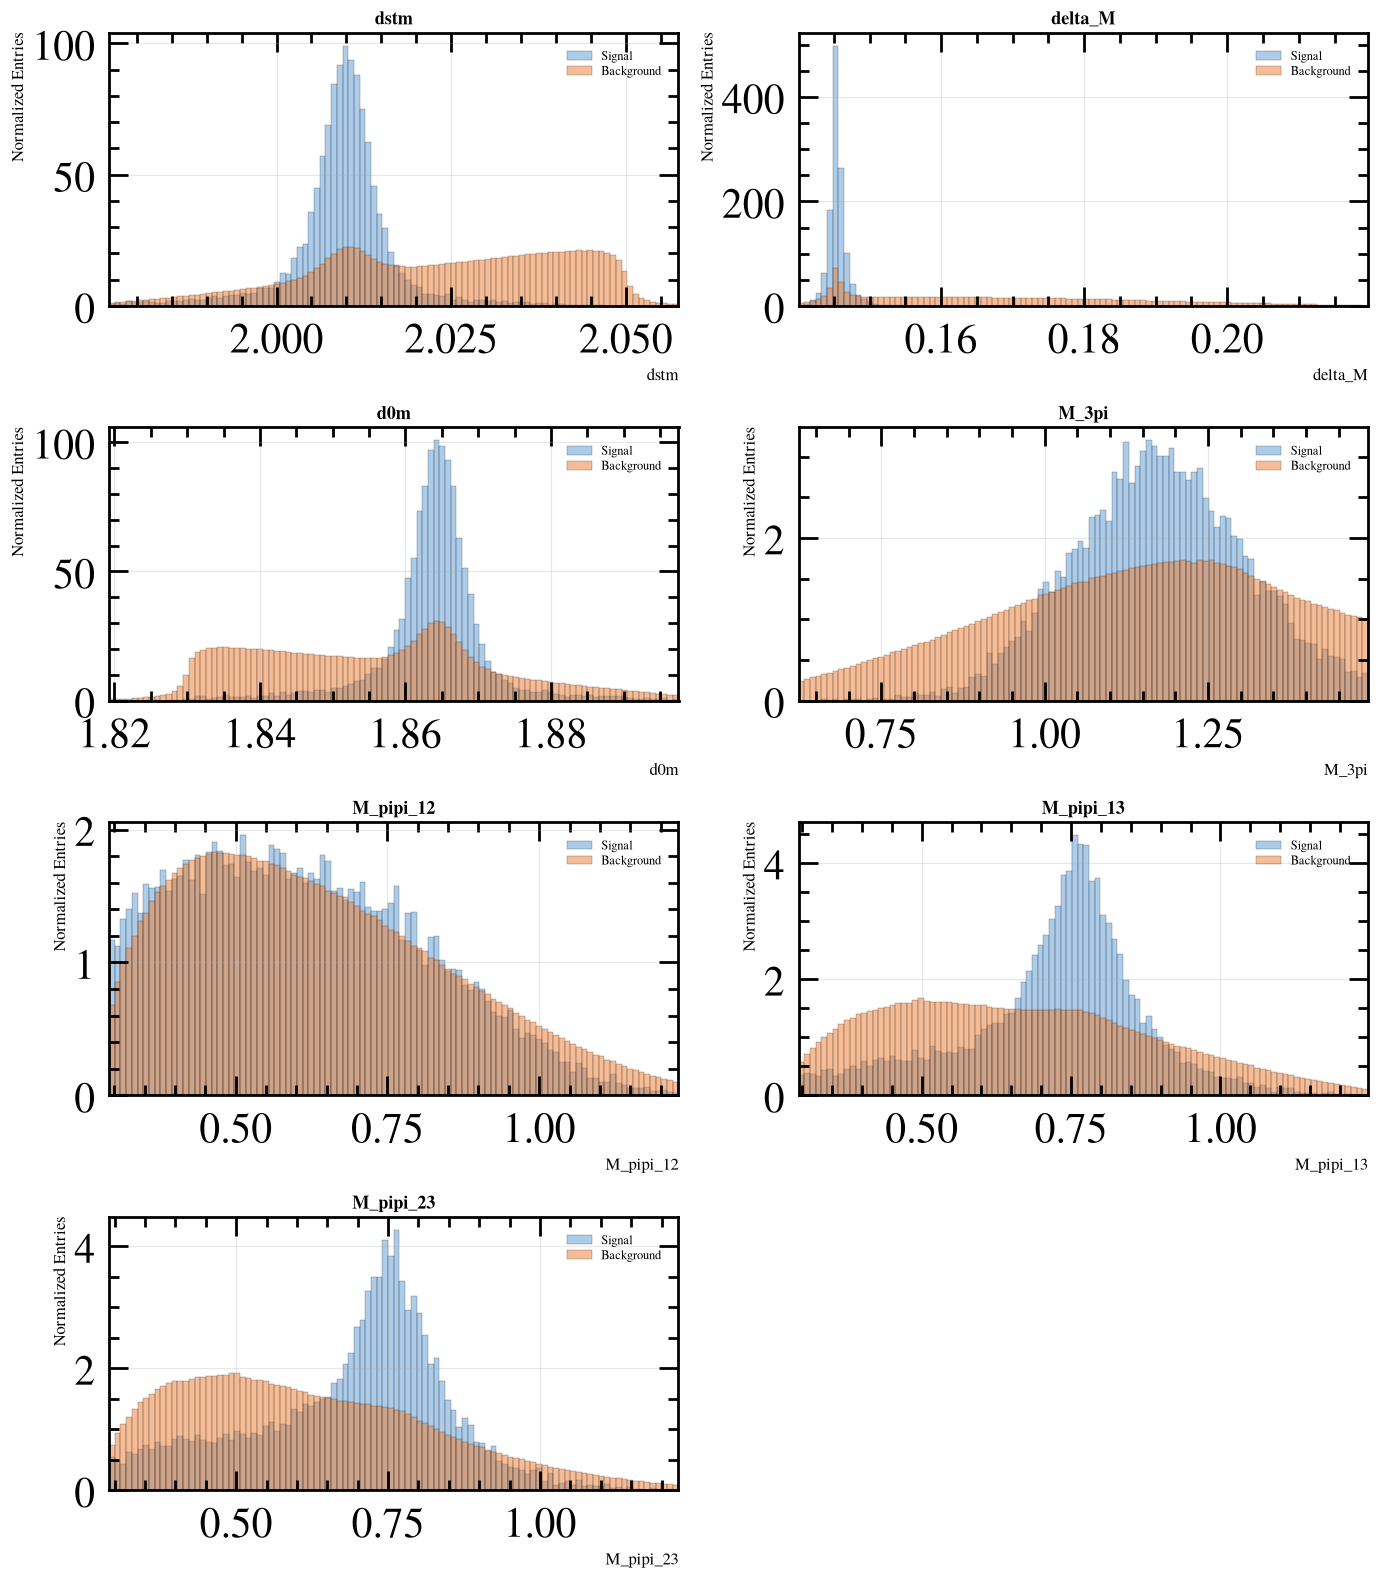

In [5]:
plt.style.use(hep.style.LHCb2)

# -----------------------------------------------------------------------
# Helper to get a sane plotting range from data quantiles
# instead of relying on default matplotlib auto-ranging, which is easily
# dominated by long tails / outliers.
# -----------------------------------------------------------------------
def quantile_range(series, q_lo=0.005, q_hi=0.995):
    quantiles_to_compute = [q_lo, q_hi]
    quantiles = np.percentile(series.dropna(), [q * 100 for q in quantiles_to_compute])
    return quantiles.tolist()

# List of mass-related features to plot.

mass_features = [
    "dstm",          # D* mass
    "delta_M",       # M(D*) - M(D0)   
    "d0m",           # D0 mass
    "M_3pi",         # Reconstructed 3pi mass (== old 'taum')
    "M_pipi_12",     # Invariant mass of pion pair 1-2 (same-sign)
    "M_pipi_13",     # Invariant mass of pion pair 1-3 (opposite-sign)
    "M_pipi_23",     # Invariant mass of pion pair 2-3 (opposite-sign)
]

n_cols = 2
n_rows = (len(mass_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes]

for idx, feature in enumerate(mass_features):
    ax = axes[idx]

    signal_vals = df_all.query("sigissig == 1")[feature].dropna()
    bkg_vals = df_all.query("sigissig != 1")[feature].dropna()

    # range set from the 0.5%-99.5% quantiles of the
    # combined (signal+background) distribution, not the raw min/max.
    combined = pd.concat([signal_vals, bkg_vals])
    plot_range = quantile_range(combined)

    ax.hist(signal_vals, bins=100, range=plot_range, density=True, alpha=0.5,
            color='#5B9BD5', edgecolor='black', linewidth=0.3, label='Signal')
    ax.hist(bkg_vals, bins=100, range=plot_range, density=True, alpha=0.5,
            color='#ED7D31', edgecolor='black', linewidth=0.3, label='Background')

    ax.set_xlim(plot_range)
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Normalized Entries', fontsize=12)
    ax.set_title(feature, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# hide any unused trailing axis
for j in range(len(mass_features), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


# PART 4: GENERAL PRE-CUTS AND LABELING

## Pre-Cuts

After feature engineering, a set of general pre-cuts is applied uniformly to
all events in the combined dataframe. These cuts remove poorly reconstructed
events and improve the signal-to-background ratio before BDT training.

| Cut | Variable | Condition | Purpose |
|-----|----------|-----------|---------|
| Tag photon multiplicity | `tagnph` | `< 9` | Remove events with excessive photons on tag side |
| Energy resolution difference | `eresdiff` | `< 0.6` | Ensure good energy reconstruction |
| Tag-side energy | `tagde` | `< 0.1` | Remove poorly reconstructed tag-side events |
| Delta M | `delta_M` | `0.140 < delta_M < 0.151` | D* mass difference window around the nominal 0.145 GeV value |
| 3-pion mass | `M_3pi` (`taum`) | `> 0.9` | Reject badly reconstructed tau candidates |
| Tag vertex chi2 | `tagchi2` | `< 50` *(placeholder, TODO tune)* | Reject poor tag-side vertex fits -- **replaces the `tagpval` cut** |
| Tag-side ROE charged tracks | `tagnchroe` | `< 8` *(placeholder, TODO tune)* | Reject events with excess charged activity in the rest-of-event on the tag side |
| Total event tracks | `nTracks` | `2 < nTracks < 12` *(placeholder, TODO tune)* | Basic event-level sanity range |
| Tag-side lepton veto | `tagne + tagnmu` | `== 0` | Suppress semileptonic tag-side backgrounds |

**Change from the previous version:** the `tagpval` cut has been removed
and replaced by the `tagchi2`/`tagnchroe`/`nTracks`/lepton-veto set above.
The numeric thresholds on the three new continuous variables are
placeholders and need to be tuned against the plotted distributions below
once run on real data.

All cuts (except the lepton veto, which is boolean-like and shown
separately) are defined once in a single `PRECUTS` dict and applied
identically to signal and background samples. The diagnostic plots below
show each variable over its **full range** (with `delta_M` given a
narrower plotting window so its peak is actually visible), split into
**signal vs. background**, with **log-y** only for `tagde`/`tagchi2`
(`eresdiff` is now plotted on a linear scale), and vertical line(s) marking
exactly where the applied cut sits -- since the plotting cell reads from
the same `PRECUTS` dict used to apply the cuts, the two can never drift out
of sync.

---

## Labeling Strategy

After pre-cuts, the `label` column is created:

| Label | Value | Description |
|-------|-------|--------------|
| Signal | `1` | Events where `sigissig == 1` (truth-matched signal candidates) |
| Background | `0` | Everything else, including: |

- Mis-reconstructed events from signal MC (`sigissig != 1`)
- Dedicated background samples (`ccB0`, `chB0`), plus `mixB0` (already
  pre-filtered to `sigissig == 0` at load time)

This unified labeling ensures that all non-signal candidates are treated as
background, regardless of their origin.


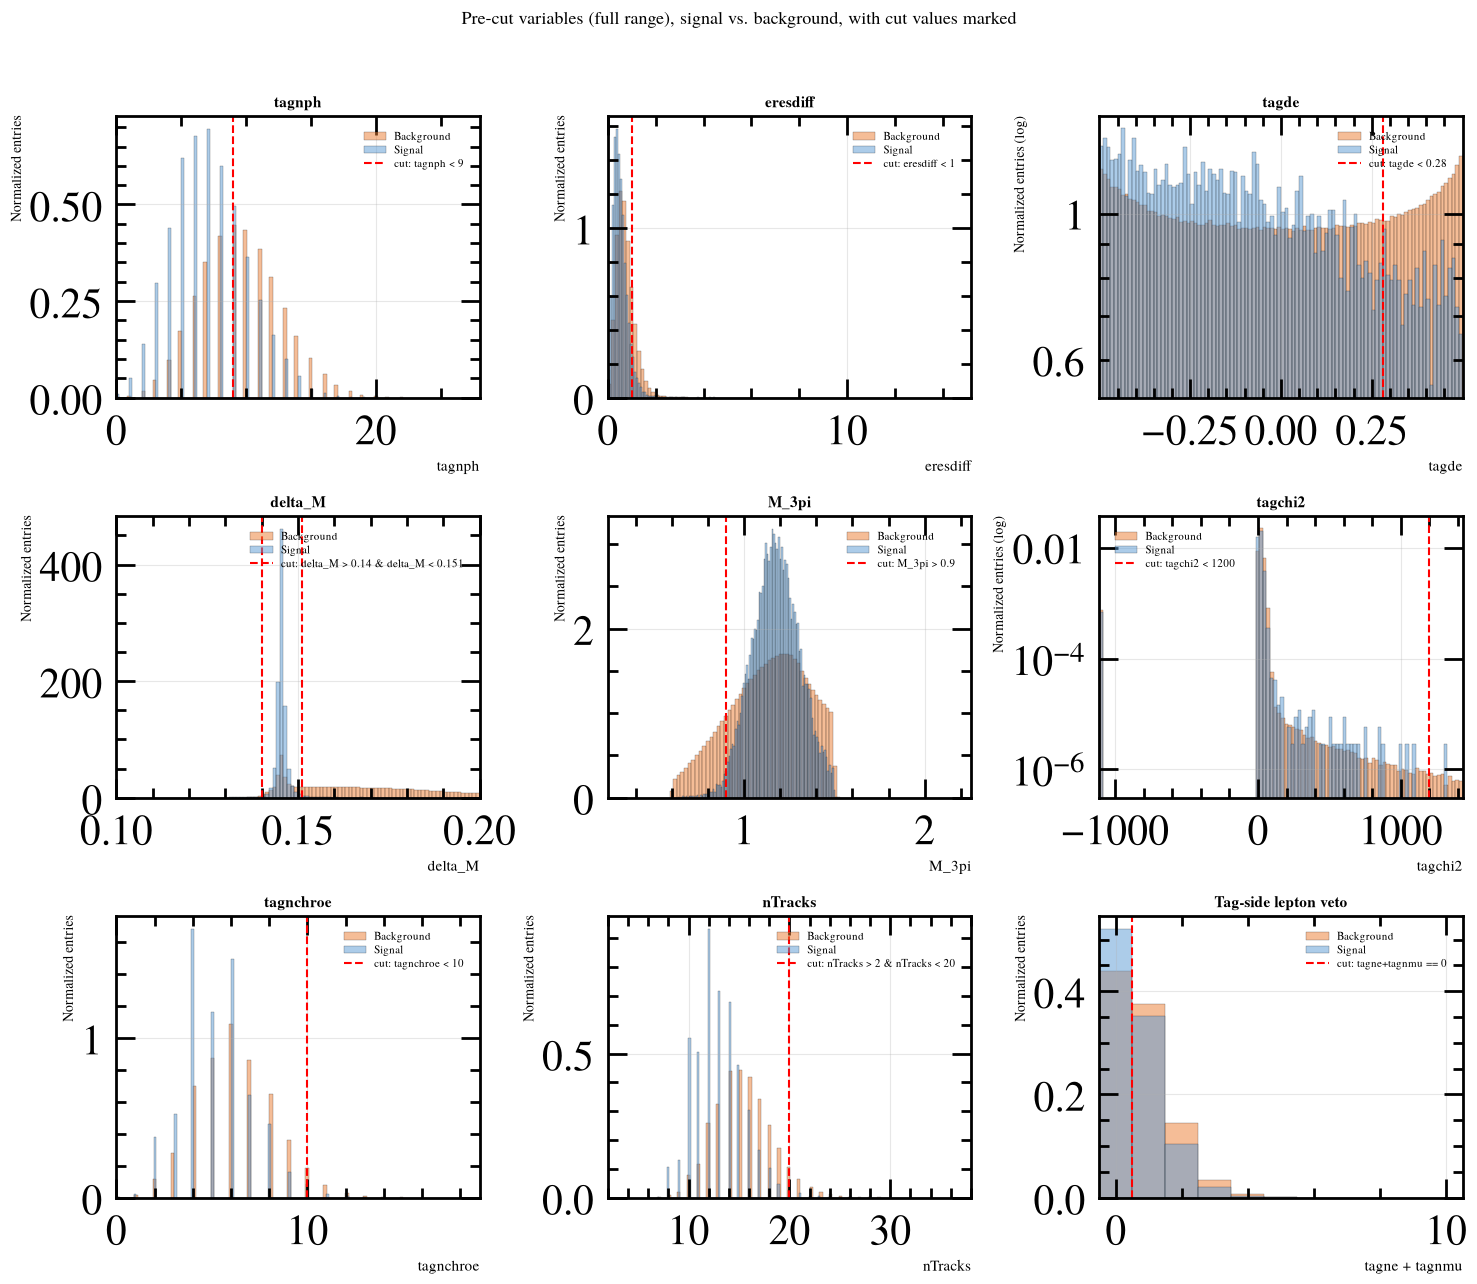

In [6]:
# =============================================================================
# Suggestion: show pre-cut variables in FULL range, split into signal vs.
# background, with log-y where the distribution is long-tailed/peaked, and
# vertical line(s) at the cut value(s), to visually justify each pre-cut.
#
# Changes per latest feedback:
#  - eresdiff: log-y turned OFF (linear scale requested).
#  - delta_M: plotting range narrowed so the peak near the nominal 0.145 GeV
#    split is actually visible (previously the full-range histogram spread
#    the peak into invisibility).
#  - tagpval cut REMOVED. Replaced by a small set of alternative precuts to
#    tune instead: tag vertex chi2 (tagchi2), number of charged tracks in
#    the ROE on the tag side (tagnchroe), total number of tracks in the
#    event (nTracks), and a tag-side lepton veto (tagne + tagnmu == 0).
#    TODO: the numeric thresholds below for these four are PLACEHOLDERS -
#    please tune them by eye against the plotted distributions once run on
#    real data; they are not yet optimized.
# =============================================================================
PRECUTS = {
    # variable:  (lower_bound_or_None, upper_bound_or_None, log_y, plot_range_or_None)
    "tagnph":     (None,   9,      False, None),
    "eresdiff":   (None,   1,    False, None),          # log-y turned off
    "tagde":      (None,   0.28,    True,  None),
    "delta_M":    (0.140,  0.151,  False, (0.10, 0.20)),  # narrowed plot range
    "M_3pi":      (0.9,    None,   False, None),
    "tagchi2":    (None,   1200,   True,  None),          # NEW - TODO tune threshold
    "tagnchroe":  (None,   10,      False, None),          # NEW - TODO tune threshold
    "nTracks":    (2,      20,     False, None),          # NEW - TODO tune threshold
}

n_cols = 3
n_rows = (len(PRECUTS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.2 * n_rows))
axes = axes.flatten()

for idx, (var, (lo, hi, logy, plot_range)) in enumerate(PRECUTS.items()):
    ax = axes[idx]
    sig_vals = df_all.loc[df_all["sigissig"] == 1, var].dropna()
    bkg_vals = df_all.loc[df_all["sigissig"] != 1, var].dropna()

    ax.hist(bkg_vals, bins=100, range=plot_range, color='#ED7D31', alpha=0.5,
            edgecolor='black', linewidth=0.3, label='Background', density=True)
    ax.hist(sig_vals, bins=100, range=plot_range, color='#5B9BD5', alpha=0.5,
            edgecolor='black', linewidth=0.3, label='Signal', density=True)

    cut_label_parts = []
    if lo is not None:
        ax.axvline(lo, color='red', linestyle='--', linewidth=1.5)
        cut_label_parts.append(f'{var} > {lo}')
    if hi is not None:
        ax.axvline(hi, color='red', linestyle='--', linewidth=1.5)
        cut_label_parts.append(f'{var} < {hi}')
    ax.plot([], [], color='red', linestyle='--', linewidth=1.5,
            label='cut: ' + ' & '.join(cut_label_parts))

    if logy:
        ax.set_yscale('log')
    ax.set_xlabel(var, fontsize=11)
    ax.set_ylabel('Normalized entries' + (' (log)' if logy else ''), fontsize=10)
    ax.set_title(var, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Lepton veto: shown separately since it's a discrete/boolean-like cut
# rather than a continuous distribution with a threshold line.
ax = axes[len(PRECUTS)]
lepton_count_sig = (df_all.loc[df_all["sigissig"] == 1, "tagne"]
                     + df_all.loc[df_all["sigissig"] == 1, "tagnmu"])
lepton_count_bkg = (df_all.loc[df_all["sigissig"] != 1, "tagne"]
                     + df_all.loc[df_all["sigissig"] != 1, "tagnmu"])
bins_lep = np.arange(0, max(lepton_count_sig.max(), lepton_count_bkg.max()) + 2) - 0.5
ax.hist(lepton_count_bkg, bins=bins_lep, color='#ED7D31', alpha=0.5,
        edgecolor='black', linewidth=0.3, label='Background', density=True)
ax.hist(lepton_count_sig, bins=bins_lep, color='#5B9BD5', alpha=0.5,
        edgecolor='black', linewidth=0.3, label='Signal', density=True)
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='cut: tagne+tagnmu == 0')
ax.set_xlabel('tagne + tagnmu', fontsize=11)
ax.set_ylabel('Normalized entries', fontsize=10)
ax.set_title('Tag-side lepton veto', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

for j in range(len(PRECUTS) + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Pre-cut variables (full range), signal vs. background, with cut values marked',
              fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [7]:
# =============================================================================
# PART 4: APPLY GENERAL PRE-CUTS to the combined dataframe. Uses the same
# PRECUTS dict defined and plotted just above, so the applied selection can
# never drift out of sync with the diagnostic plot. tagpval cut removed;
# tagchi2/tagnchroe/nTracks (all TODO-tuned) and a tag-side lepton veto
# (tagne + tagnmu == 0) added instead, per latest feedback.
# =============================================================================
print("\n" + "=" * 60)
print("STEP 3: GENERAL PRE-CUTS")
print("=" * 60)

general_cuts = pd.Series(True, index=df_all.index)
for var, (lo, hi, _logy, _plot_range) in PRECUTS.items():
    if lo is not None:
        general_cuts &= (df_all[var] > lo)
    if hi is not None:
        general_cuts &= (df_all[var] < hi)
    print(f"  applying: {lo if lo is not None else '-inf'} < {var} < "
          f"{hi if hi is not None else '+inf'}")

# Tag-side lepton veto (NEW, replaces tagpval cut)
general_cuts &= ((df_all["tagne"] + df_all["tagnmu"]) == 0)
print("  applying: tagne + tagnmu == 0  (tag-side lepton veto)")

n_before = len(df_all)
df_all = df_all[general_cuts].reset_index(drop=True)
print(f"Combined: {n_before} -> {len(df_all)} ({100*len(df_all)/n_before:.1f}% retained)")

# =============================================================================
# STEP 4: LABEL - signal is sigissig==1 (post cuts), everything else is
# background (combinatorics within signal MC AND generic bkg samples,
# treated uniformly since they're now in the same combined dataframe)
# =============================================================================
print("\n" + "=" * 60)
print("STEP 4: LABELING")
print("=" * 60)

df_all["label"] = (df_all["sigissig"] == 1).astype(int)

n_signal = (df_all["label"] == 1).sum()
n_bkg = (df_all["label"] == 0).sum()
print(f"Signal (sigissig==1):     {n_signal}")
print(f"Background (sigissig!=1): {n_bkg}")
print(f"Signal fraction: {df_all['label'].mean():.4f}")



STEP 3: GENERAL PRE-CUTS
  applying: -inf < tagnph < 9
  applying: -inf < eresdiff < 1
  applying: -inf < tagde < 0.28
  applying: 0.14 < delta_M < 0.151
  applying: 0.9 < M_3pi < +inf
  applying: -inf < tagchi2 < 1200
  applying: -inf < tagnchroe < 10
  applying: 2 < nTracks < 20
  applying: tagne + tagnmu == 0  (tag-side lepton veto)
Combined: 4042462 -> 111260 (2.8% retained)

STEP 4: LABELING
Signal (sigissig==1):     3684
Background (sigissig!=1): 107576
Signal fraction: 0.0331


In [8]:
# =============================================================================
# Quick numerical sanity check of the triple product right after labeling
# (no plot here - the polished signal/background, before/after-BDT figures
# live in the dedicated section further down, so this isn't duplicated).
# =============================================================================
tp_valid = df_all["triple_product_reco"].dropna()
tp_valid = tp_valid[np.isfinite(tp_valid)]

sig_mask = df_all.loc[tp_valid.index, "label"] == 1
bkg_mask = df_all.loc[tp_valid.index, "label"] == 0

n_pos_sig = int((tp_valid[sig_mask] > 0).sum())
n_neg_sig = int((tp_valid[sig_mask] < 0).sum())
n_pos_bkg = int((tp_valid[bkg_mask] > 0).sum())
n_neg_bkg = int((tp_valid[bkg_mask] < 0).sum())

A_sig, A_sig_err = asymmetry_with_error(n_pos_sig, n_neg_sig)
A_bkg, A_bkg_err = asymmetry_with_error(n_pos_bkg, n_neg_bkg)

print("Triple product, before BDT selection:")
print(f"  Signal:     N(+)={n_pos_sig}, N(-)={n_neg_sig}, "
      f"asymmetry={A_sig:.4f} +/- {A_sig_err:.4f}")
print(f"  Background: N(+)={n_pos_bkg}, N(-)={n_neg_bkg}, "
      f"asymmetry={A_bkg:.4f} +/- {A_bkg_err:.4f}")


Triple product, before BDT selection:
  Signal:     N(+)=1847, N(-)=1837, asymmetry=0.0027 +/- 0.0165
  Background: N(+)=54057, N(-)=53519, asymmetry=0.0050 +/- 0.0030


# rho Resonance in tau -> 3pi nu Decay

## Sanity Mask

Basic quality cuts to ensure D* and D0 masses are within reasonable ranges:

| Variable | Condition | Purpose |
|----------|-----------|---------|
| `dstm` | (1.9, 2.1) GeV | D* mass window |
| `d0m` | (1.7, 2.0) GeV | D0 mass window |

---

## Folded Mass Plot (M_pipi)

All three pi-pi pair combinations are combined into a single histogram:

- $M_{12} = M(\pi_1\pi_2)$ (same-sign pair)
- $M_{13} = M(\pi_1\pi_3)$ (opposite-sign pair)
- $M_{23} = M(\pi_2\pi_3)$ (opposite-sign pair)

**Signal** (blue): Clear peak at the rho(770) mass (0.775 GeV) from
opposite-sign pion pairs.
**Background** (red): distribution with no significant structure.

---

## Dalitz Plot (Signal Only)

Since we reconstruct `tau -> pi+ pi+ pi-`, pions 1 and 2
are same-sign and do **not** form the rho resonance; only the (pi1, pi3) and
(pi2, pi3) opposite-sign combinations do. The Dalitz plot is therefore drawn
using the two *opposite-sign* pair masses:

- $x$-axis: $M^2(\pi_1\pi_3)$
- $y$-axis: $M^2(\pi_2\pi_3)$

instead of the previous (M12, M13) choice, which mixed one same-sign and one
opposite-sign pair.

A cross-check Dalitz plot using the momentum-ordered `m_fastpi_pi` /
`m_slowpi_pi` pair is also shown, which should look
consistent with the (M13, M23) plot up to the fast/slow relabeling.


Events passing sanity mask: 111259 / 111260


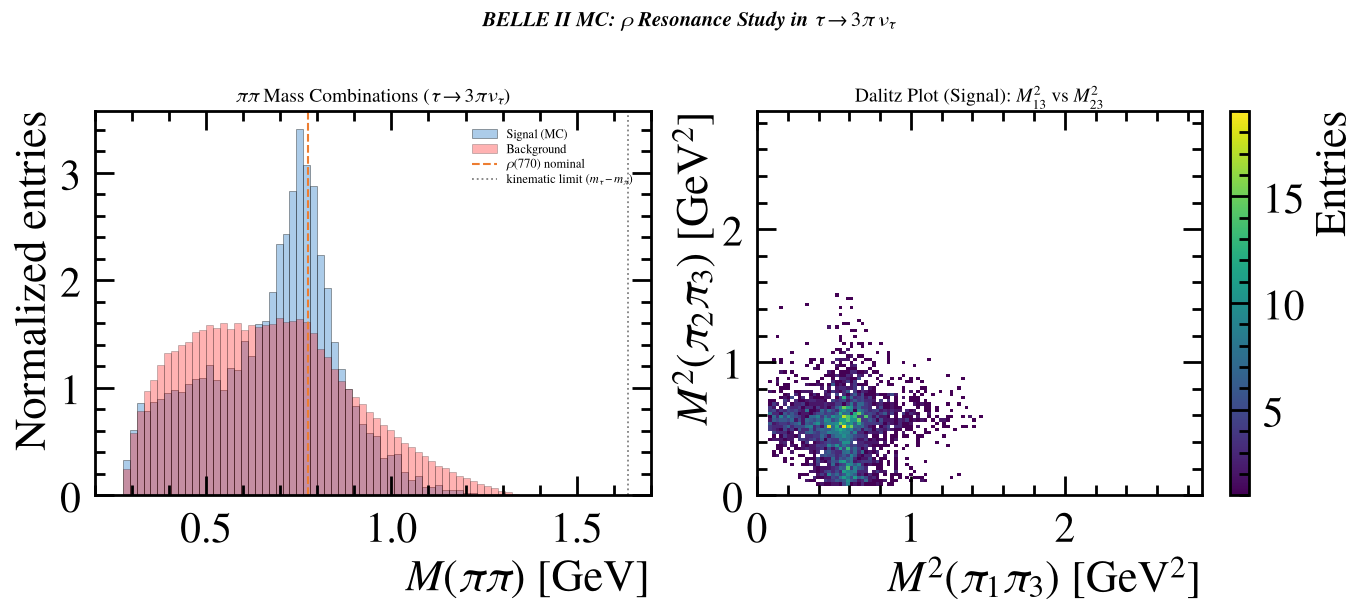

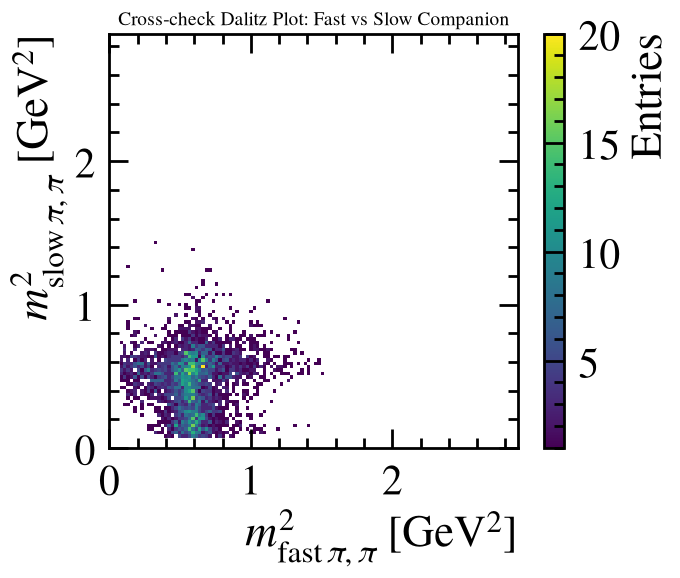

In [9]:


plt.style.use(hep.style.LHCb2)

# =========================================================================
# Sanity mask and plotting
# =========================================================================
df_all["sanity_ok"] = (
    (df_all["dstm"] > 1.9) & (df_all["dstm"] < 2.1) &
    (df_all["d0m"] > 1.7) & (df_all["d0m"] < 2.0)
)

print(f"\nEvents passing sanity mask: {df_all['sanity_ok'].sum()} / {len(df_all)}")

query_signal = "sanity_ok == True & label == 1"
query_bkg = "sanity_ok == True & label == 0"

# Increased figure width slightly to accommodate the 2D plot colorbar properly
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------------------------------------------------------------
# PLOT 1: Combined pi+pi- Mass (Projection)
# -------------------------------------------------------------------------
ax = axes[0]
df_sig_cut = df_all.query(query_signal)
bkg_df_cut = df_all.query(query_bkg)

sig_folded = pd.concat([
    df_sig_cut["M_pipi_12"], df_sig_cut["M_pipi_13"], df_sig_cut["M_pipi_23"]
]).dropna()
bkg_folded = pd.concat([
    bkg_df_cut["M_pipi_12"], bkg_df_cut["M_pipi_13"], bkg_df_cut["M_pipi_23"]
]).dropna()


M_TAU = 1.77686
mpipi_range = (0.2, 1.7)

ax.hist(sig_folded, bins=80, range=mpipi_range, color='#5B9BD5',
        edgecolor='black', linewidth=0.5, alpha=0.5, density=True, label='Signal (MC)')
ax.hist(bkg_folded, bins=80, range=mpipi_range, color='red',
        edgecolor='black', linewidth=0.5, alpha=0.3, density=True, label='Background')

ax.axvline(M_RHO, color='#ED7D31', linestyle='--', linewidth=1.5, label=r'$\rho(770)$ nominal')
ax.axvline(M_TAU - M_PI, color='gray', linestyle=':', linewidth=1.3,
           label=r'kinematic limit ($m_\tau - m_\pi$)')
ax.set_xlabel(r'$M(\pi\pi)$ $[\mathrm{GeV}]$')
ax.set_ylabel('Normalized entries')
ax.set_title(r'$\pi\pi$ Mass Combinations ($\tau \to 3\pi\nu_\tau$)', fontsize=14)
ax.legend(fontsize=9, loc='upper right')

# -------------------------------------------------------------------------
# PLOT 2: Main Dalitz plot (M13^2 vs M23^2)
# -------------------------------------------------------------------------
ax = axes[1]

dalitz_max = mpipi_range[1]**2  # (1.7 GeV)^2
dalitz_range = [[0.0, dalitz_max], [0.0, dalitz_max]]

h = ax.hist2d(df_sig_cut["M_pipi_13"]**2, df_sig_cut["M_pipi_23"]**2,
              bins=120, range=dalitz_range, cmap='viridis', cmin=1)

ax.set_xlabel(r'$M^2(\pi_1\pi_3)$ $[\mathrm{GeV}^2]$')
ax.set_ylabel(r'$M^2(\pi_2\pi_3)$ $[\mathrm{GeV}^2]$')
ax.set_title(r'Dalitz Plot (Signal): $M^2_{13}$ vs $M^2_{23}$', fontsize=14)
fig.colorbar(h[3], ax=ax, label='Entries')


fig.suptitle(r'BELLE II MC: $\rho$ Resonance Study in $\tau \to 3\pi\,\nu_\tau$',
             fontsize=15, style='italic', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# PLOT 3: Cross-check Dalitz plot (Fast vs Slow)
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))
h2 = ax.hist2d(df_sig_cut["m_fastpi_pi"]**2, df_sig_cut["m_slowpi_pi"]**2,
               bins=120, range=dalitz_range, cmap='viridis', cmin=1)

ax.set_xlabel(r'$m^2_{\mathrm{fast}\,\pi,\pi}$ $[\mathrm{GeV}^2]$')
ax.set_ylabel(r'$m^2_{\mathrm{slow}\,\pi,\pi}$ $[\mathrm{GeV}^2]$')
ax.set_title('Cross-check Dalitz Plot: Fast vs Slow Companion', fontsize=14)
fig.colorbar(h2[3], ax=ax, label='Entries')
plt.tight_layout()
plt.show()


# PART 3b: Correlation Study

Before finalizing the BDT feature list, check the correlation matrices for
signal and background separately (now over essentially the full candidate
feature list, including `tauecmw`/`taupcmw` and the `M_pipi_*`/companion-pion
mass family), and remove features that are strongly correlated with each
other (they add little extra separation power while increasing overtraining
risk and diluting feature-importance rankings).

The correlation threshold is set to `0.5` (loosened from the earlier
`0.85`, per feedback), and for every flagged pair the notebook picks which
feature to keep using each feature's individual KS (Kolmogorov-Smirnov)
separation power between signal and background, rather than an arbitrary
choice. The `features` list used for BDT training just below is then built
programmatically from this recommendation, so the decision is reproducible
and tied to the actual data rather than to assumptions made ahead of time.


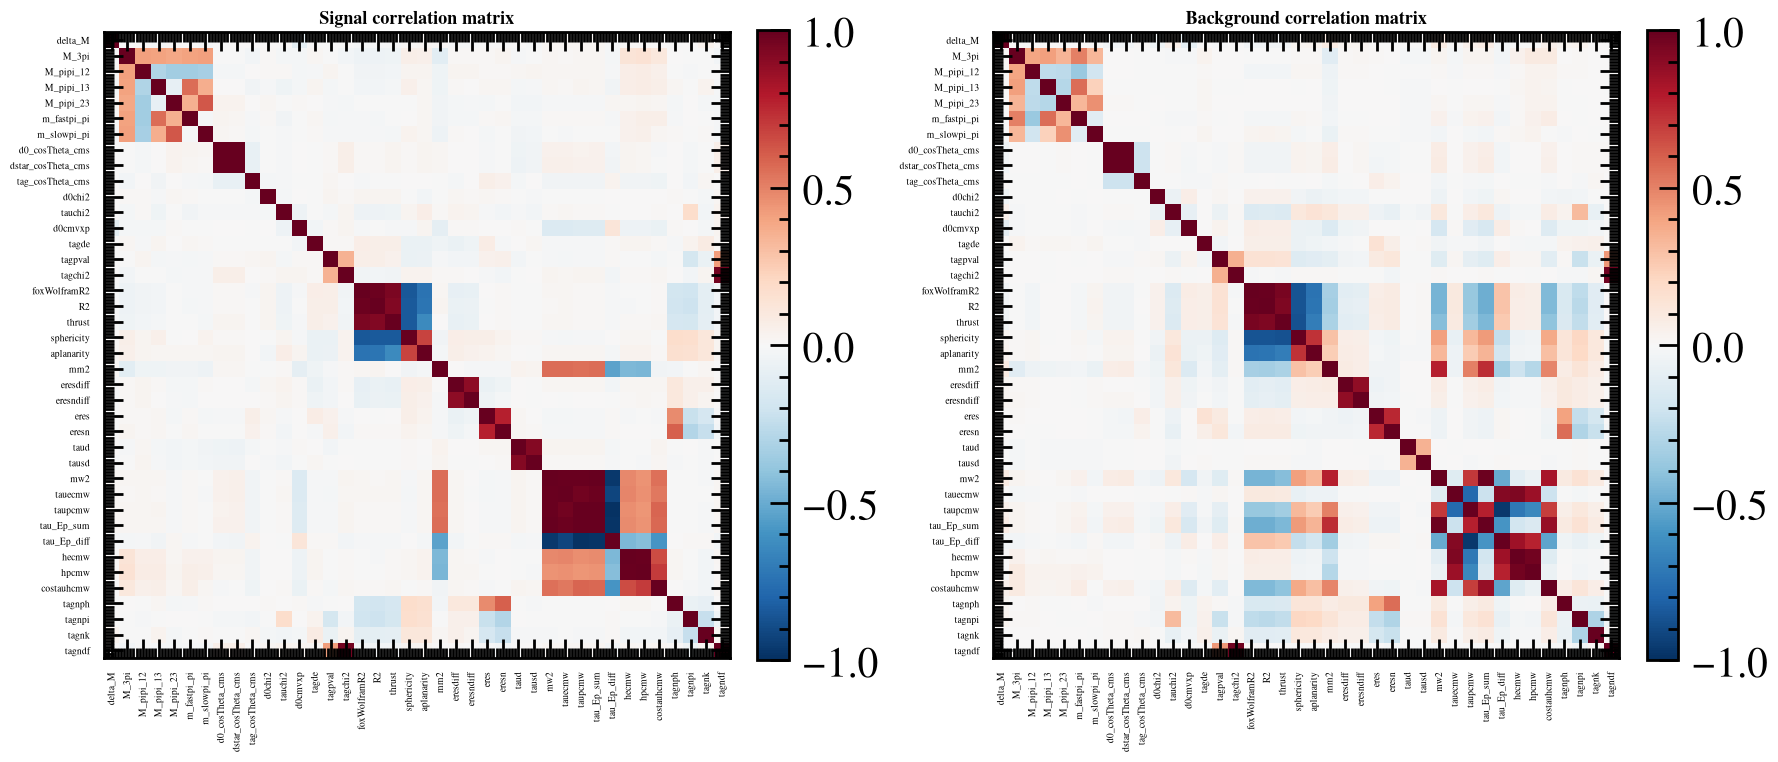

Feature pairs with |correlation| > 0.5 (in signal or background),
with a data-driven keep/drop recommendation based on KS separation power:
----------------------------------------------------------------------------------------------------
  M_3pi            <-> m_fastpi_pi       r_sig=+0.406  r_bkg=+0.501  KS[M_3pi]=0.099  KS[m_fastpi_pi]=0.158  ->  keep m_fastpi_pi      drop M_3pi
  M_pipi_13        <-> m_fastpi_pi       r_sig=+0.560  r_bkg=+0.561  KS[M_pipi_13]=0.187  KS[m_fastpi_pi]=0.158  ->  keep M_pipi_13        drop m_fastpi_pi
  M_pipi_23        <-> m_slowpi_pi       r_sig=+0.622  r_bkg=+0.457  KS[M_pipi_23]=0.215  KS[m_slowpi_pi]=0.299  ->  keep m_slowpi_pi      drop M_pipi_23
  d0_cosTheta_cms  <-> dstar_cosTheta_cms  r_sig=+0.999  r_bkg=+0.999  KS[d0_cosTheta_cms]=0.039  KS[dstar_cosTheta_cms]=0.040  ->  keep dstar_cosTheta_cms drop d0_cosTheta_cms
  tagchi2          <-> tagndf            r_sig=+0.968  r_bkg=+0.973  KS[tagchi2]=0.124  KS[tagndf]=0.120  ->  keep tagchi2    

In [10]:
# =========================================================================
# New features for the tauecmw/taupcmw pair
# =========================================================================
df_all["tau_Ep_sum"] = df_all["tauecmw"] + df_all["taupcmw"]
df_all["tau_Ep_diff"] = df_all["tauecmw"] - df_all["taupcmw"]

# =========================================================================
# candidate list expanded to cover everything
# being considered as a BDT input, not just a hand-picked subset, so the
# correlation study is actually representative of the final feature list.
#
# eresndiff added alongside eresdiff (per feedback: eresndiff might be a
# better-performing version of the same energy-residual-difference idea) -
# the KS-based pick logic below will pick whichever of the two actually
# separates signal/background better, and correlation with the other will
# flag the loser for drop automatically.
# =========================================================================
corr_candidate_features = [
    "delta_M", "M_3pi", "M_pipi_12", "M_pipi_13", "M_pipi_23",
    "m_fastpi_pi", "m_slowpi_pi",
    "d0_cosTheta_cms", "dstar_cosTheta_cms", "tag_cosTheta_cms",
    "d0chi2", "tauchi2", "d0cmvxp", "tagde", "tagpval", "tagchi2",
    "foxWolframR2", "R2", "thrust", "sphericity", "aplanarity",
    "mm2", "eresdiff", "eresndiff", "eres", "eresn",
    "taud", "tausd", "mw2",
    "tauecmw", "taupcmw", "tau_Ep_sum", "tau_Ep_diff",
    "hecmw", "hpcmw", "costauhcmw",
    "tagnph", "tagnpi", "tagnk", "tagndf",
]
corr_candidate_features = [f for f in corr_candidate_features if f in df_all.columns]

sig_corr = df_all.loc[df_all["label"] == 1, corr_candidate_features].corr()
bkg_corr = df_all.loc[df_all["label"] == 0, corr_candidate_features].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, mat, title in zip(axes, [sig_corr, bkg_corr], ["Signal", "Background"]):
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(len(corr_candidate_features)))
    ax.set_yticks(range(len(corr_candidate_features)))
    ax.set_xticklabels(corr_candidate_features, rotation=90, fontsize=7)
    ax.set_yticklabels(corr_candidate_features, fontsize=7)
    ax.set_title(f'{title} correlation matrix', fontsize=13, fontweight='bold')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# =========================================================================
# lower threshold to 0.5, and for every flagged pair, pick
# which one to keep using separation-power score
# (KS statistic between the signal and background distributions of each
# feature) rather than an arbitrary choice - the one with MORE separation
# power is kept.
# =========================================================================
def feature_separation_score(feat):
    s = df_all.loc[df_all["label"] == 1, feat].dropna()
    b = df_all.loc[df_all["label"] == 0, feat].dropna()
    if len(s) == 0 or len(b) == 0:
        return 0.0
    stat, _ = ks_2samp(s, b)
    return stat

separation_scores = {f: feature_separation_score(f) for f in corr_candidate_features}

threshold = 0.5
cols = corr_candidate_features
flagged_pairs = []
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r_sig = sig_corr.iloc[i, j]
        r_bkg = bkg_corr.iloc[i, j]
        if abs(r_sig) > threshold or abs(r_bkg) > threshold:
            flagged_pairs.append((cols[i], cols[j], r_sig, r_bkg))

print(f"Feature pairs with |correlation| > {threshold} (in signal or background),")
print("with a data-driven keep/drop recommendation based on KS separation power:")
print("-" * 100)
recommended_drops = set()
for f1, f2, r_sig, r_bkg in flagged_pairs:
    s1, s2 = separation_scores[f1], separation_scores[f2]
    keep, drop = (f1, f2) if s1 >= s2 else (f2, f1)
    recommended_drops.add(drop)
    print(f"  {f1:16s} <-> {f2:16s}  r_sig={r_sig:+.3f}  r_bkg={r_bkg:+.3f}  "
          f"KS[{f1}]={s1:.3f}  KS[{f2}]={s2:.3f}  ->  keep {keep:16s} drop {drop}")

print()
print(f"Recommended drops ({len(recommended_drops)}): {sorted(recommended_drops)}")
print()
print("Individual KS separation scores (higher = more sig/bkg separation):")
for f, s in sorted(separation_scores.items(), key=lambda x: -x[1]):
    print(f"  {f:16s} {s:.3f}")


### Stability Check: Varying the Correlation Threshold

The keep/drop recommendation above used a fixed threshold of `0.5`. To check
how sensitive the final feature list is to that choice, the same
flag-then-KS-pick procedure is repeated at `0.4` and `0.6` below, reusing
the already-computed `sig_corr`, `bkg_corr`, and `separation_scores` (no
need to rebuild the correlation matrices). A stable method should recommend
mostly the same drops at all three thresholds, with only a few
borderline pairs (correlation just above/below 0.5) appearing or
disappearing.

In [11]:
# =========================================================================
# Threshold stability check: repeat the flag + KS-based keep/drop logic at
# a few different correlation thresholds, reusing sig_corr/bkg_corr/
# separation_scores already computed above.
# =========================================================================
def recommend_drops_at_threshold(threshold, cols, sig_corr, bkg_corr, separation_scores):
    flagged = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r_sig = sig_corr.iloc[i, j]
            r_bkg = bkg_corr.iloc[i, j]
            if abs(r_sig) > threshold or abs(r_bkg) > threshold:
                flagged.append((cols[i], cols[j], r_sig, r_bkg))
    drops = set()
    for f1, f2, r_sig, r_bkg in flagged:
        s1, s2 = separation_scores[f1], separation_scores[f2]
        _keep, drop = (f1, f2) if s1 >= s2 else (f2, f1)
        drops.add(drop)
    return drops, flagged

thresholds_to_check = [0.4, 0.5, 0.6]
drops_by_threshold = {}
for thr in thresholds_to_check:
    drops, flagged = recommend_drops_at_threshold(
        thr, corr_candidate_features, sig_corr, bkg_corr, separation_scores)
    drops_by_threshold[thr] = drops
    print(f"threshold = {thr}: {len(flagged)} pairs flagged, "
          f"{len(drops)} features recommended for drop")
    print(f"  drops: {sorted(drops)}")
    print()

# Compare against the baseline threshold = 0.5 used in the main pipeline
baseline = drops_by_threshold[0.5]
for thr in thresholds_to_check:
    if thr == 0.5:
        continue
    only_here = drops_by_threshold[thr] - baseline
    only_baseline = baseline - drops_by_threshold[thr]
    print(f"Threshold {thr} vs. 0.5:")
    print(f"  Additional drops at {thr} (not dropped at 0.5): {sorted(only_here) if only_here else 'none'}")
    print(f"  Drops at 0.5 not present at {thr}:             {sorted(only_baseline) if only_baseline else 'none'}")
    print()


threshold = 0.4: 71 pairs flagged, 23 features recommended for drop
  drops: ['M_3pi', 'M_pipi_12', 'M_pipi_23', 'R2', 'costauhcmw', 'd0_cosTheta_cms', 'eres', 'eresn', 'eresndiff', 'foxWolframR2', 'hecmw', 'hpcmw', 'm_fastpi_pi', 'mm2', 'mw2', 'sphericity', 'tagndf', 'tagpval', 'tau_Ep_diff', 'tau_Ep_sum', 'taud', 'taupcmw', 'thrust']

threshold = 0.5: 48 pairs flagged, 21 features recommended for drop
  drops: ['M_3pi', 'M_pipi_23', 'R2', 'costauhcmw', 'd0_cosTheta_cms', 'eres', 'eresn', 'eresndiff', 'foxWolframR2', 'hecmw', 'hpcmw', 'm_fastpi_pi', 'mm2', 'mw2', 'sphericity', 'tagndf', 'tau_Ep_diff', 'tau_Ep_sum', 'taud', 'taupcmw', 'thrust']

threshold = 0.6: 40 pairs flagged, 17 features recommended for drop
  drops: ['M_pipi_23', 'R2', 'costauhcmw', 'd0_cosTheta_cms', 'eres', 'eresndiff', 'foxWolframR2', 'hecmw', 'hpcmw', 'mw2', 'sphericity', 'tagndf', 'tau_Ep_diff', 'tau_Ep_sum', 'taud', 'taupcmw', 'thrust']

Threshold 0.4 vs. 0.5:
  Additional drops at 0.4 (not dropped at 0.5): 

In [12]:
print("="*60)
print("STEP 5: FEATURE SELECTION & DATA PREPARATION")
print("="*60)

# -----------------------------------------------------------------------
# triple_product_reco is OUR SIGNAL-EXTRACTION OBSERVABLE and must never be
# used as a BDT input 
# Everything else in `candidate_pool` is exactly the set considered in the
# correlation study above; `recommended_drops` (computed there, via the
# KS-based separation-power comparison for every pair with |r| > 0.5) is
# then subtracted automatically. A handful of extra raw variables not part
# of the correlation study (IDs/counters, tag vertex chi2, etc.) are added
# back in afterwards since they were never flagged as redundant.
# -----------------------------------------------------------------------
candidate_pool = list(corr_candidate_features)  # everything checked for correlation
# (d0cmvxp, tagchi2, tagpval, etc. are already part of corr_candidate_features
# above, so the full previously-used feature set is covered without needing
# to append anything extra here.)

features = [f for f in candidate_pool if f not in recommended_drops]

print(f"Candidate pool: {len(candidate_pool)} features")
print(f"Dropped as redundant (correlation study): {sorted(recommended_drops)}")
print(f"\nUsing {len(features)} features:")
for f in features:
    print(f"  - {f}")

columns_to_keep = features + ["label"]
data = df_all[columns_to_keep].dropna()

print(f"\nBefore dropna: {len(df_all)}")
print(f"After dropna:  {len(data)}")

if len(data) == 0:
    print("\nERROR: no rows survived dropna. Checking each feature individually:")
    for f in features:
        n_ok = df_all[[f, "label"]].dropna().shape[0]
        print(f"  {f:22s}: {n_ok} rows survive alone")
else:
    X = data[features]
    y = data["label"].astype(int)
    print(f"\nUsable rows: {len(data)}")
    print(f"Signal fraction: {y.mean():.4f}  "
          f"(signal={y.sum()}, background={len(y)-y.sum()})")


STEP 5: FEATURE SELECTION & DATA PREPARATION
Candidate pool: 40 features
Dropped as redundant (correlation study): ['M_3pi', 'M_pipi_23', 'R2', 'costauhcmw', 'd0_cosTheta_cms', 'eres', 'eresn', 'eresndiff', 'foxWolframR2', 'hecmw', 'hpcmw', 'm_fastpi_pi', 'mm2', 'mw2', 'sphericity', 'tagndf', 'tau_Ep_diff', 'tau_Ep_sum', 'taud', 'taupcmw', 'thrust']

Using 19 features:
  - delta_M
  - M_pipi_12
  - M_pipi_13
  - m_slowpi_pi
  - dstar_cosTheta_cms
  - tag_cosTheta_cms
  - d0chi2
  - tauchi2
  - d0cmvxp
  - tagde
  - tagpval
  - tagchi2
  - aplanarity
  - eresdiff
  - tausd
  - tauecmw
  - tagnph
  - tagnpi
  - tagnk

Before dropna: 111260
After dropna:  111260

Usable rows: 111260
Signal fraction: 0.0331  (signal=3684, background=107576)


In [13]:
print("="*60)
print("STEP 6: TRAIN/TEST SPLIT & BDT TRAINING")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} ({y_train.mean():.4f} signal)")
print(f"Test:  {len(X_test)} ({y_test.mean():.4f} signal)")

bdt = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, min_samples_leaf=500),
    n_estimators=700,
    learning_rate=0.1,
    random_state=42
)
bdt.fit(X_train, y_train)

y_score_train = bdt.decision_function(X_train)
y_score_test = bdt.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_score_test)
roc_auc_baseline_allfeatures = auc(fpr, tpr)
print(f"\nTest-set ROC AUC (baseline, all {len(features)} correlation-pruned features): {roc_auc_baseline_allfeatures:.3f}")


STEP 6: TRAIN/TEST SPLIT & BDT TRAINING
Train: 77882 (0.0331 signal)
Test:  33378 (0.0331 signal)

Test-set ROC AUC (baseline, all 19 correlation-pruned features): 0.810


## Ablation Study: Test AUC vs. Number of Features Dropped

Rather than picking an arbitrary number of low-importance features to drop
(as in the earlier `[0, 3, 5, 8]` spot-check), sweep over **every** possible
number of dropped features -- ranked from least to most important via the
baseline model's `feature_importances_` -- and retrain/re-evaluate at each
point. Plotting Test AUC vs. number of dropped features shows the actual
shape of the trade-off, and a working point (how many features can safely
be dropped) is picked directly from that shape: the largest number of drops
for which the AUC has not meaningfully degraded from the full-feature
baseline.

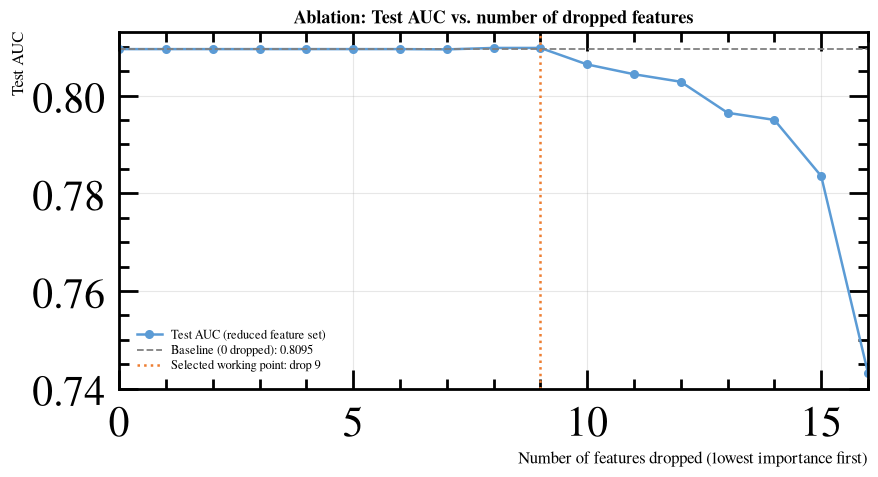

Baseline: 19 features, AUC = 0.8095
Selected working point: drop 9 features (tolerance = 0.003), AUC = 0.8098
Dropped: ['aplanarity', 'd0cmvxp', 'tagnk', 'tauchi2', 'tag_cosTheta_cms', 'tagpval', 'dstar_cosTheta_cms', 'tagde', 'tausd']

features_selected (10): ['delta_M', 'M_pipi_12', 'M_pipi_13', 'm_slowpi_pi', 'd0chi2', 'tagchi2', 'eresdiff', 'tauecmw', 'tagnph', 'tagnpi']

NOTE: AUC_DROP_TOLERANCE = 0.003 is a choice, not derived -
adjust it directly and re-run this cell if a more/less aggressive cut
looks better justified by the shape of the curve above.


In [14]:
# =========================================================================
# Full ablation sweep: drop 0, 1, 2, ... lowest-importance features (by the
# baseline model's feature_importances_) and record the Test AUC at each
# point, keeping at least 3 features.
# =========================================================================
importance_sorted = sorted(zip(features, bdt.feature_importances_), key=lambda x: -x[1])
max_drop = len(features) - 3  # keep at least 3 features
n_drop_range = list(range(0, max_drop + 1))

auc_vs_ndrop = []
for n_drop in n_drop_range:
    dropped = [f for f, _imp in importance_sorted[-n_drop:]] if n_drop > 0 else []
    kept = [f for f in features if f not in dropped]

    bdt_sub = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2, min_samples_leaf=500),
        n_estimators=700,
        learning_rate=0.1,
        random_state=42
    )
    bdt_sub.fit(X_train[kept], y_train)
    y_score_sub = bdt_sub.decision_function(X_test[kept])
    fpr_sub, tpr_sub, _ = roc_curve(y_test, y_score_sub)
    auc_sub = auc(fpr_sub, tpr_sub)
    auc_vs_ndrop.append(auc_sub)

auc_vs_ndrop = np.array(auc_vs_ndrop)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_drop_range, auc_vs_ndrop, marker='o', color='#5B9BD5', linewidth=1.8,
        markersize=5, label='Test AUC (reduced feature set)')
ax.axhline(roc_auc_baseline_allfeatures, color='gray', linestyle='--', linewidth=1.3,
           label=f'Baseline (0 dropped): {roc_auc_baseline_allfeatures:.4f}')

AUC_DROP_TOLERANCE = 0.003
ok_mask = auc_vs_ndrop >= (roc_auc_baseline_allfeatures - AUC_DROP_TOLERANCE)
N_DROP_SELECTED = int(np.max(np.array(n_drop_range)[ok_mask])) if ok_mask.any() else 0

ax.axvline(N_DROP_SELECTED, color='#ED7D31', linestyle=':', linewidth=1.8,
           label=f'Selected working point: drop {N_DROP_SELECTED}')
ax.set_xlabel('Number of features dropped (lowest importance first)', fontsize=12)
ax.set_ylabel('Test AUC', fontsize=12)
ax.set_title('Ablation: Test AUC vs. number of dropped features', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

features_dropped_selected = [f for f, _imp in importance_sorted[-N_DROP_SELECTED:]] if N_DROP_SELECTED > 0 else []
features_selected = [f for f in features if f not in features_dropped_selected]

print(f"Baseline: {len(features)} features, AUC = {roc_auc_baseline_allfeatures:.4f}")
print(f"Selected working point: drop {N_DROP_SELECTED} features "
      f"(tolerance = {AUC_DROP_TOLERANCE}), AUC = {auc_vs_ndrop[N_DROP_SELECTED]:.4f}")
print(f"Dropped: {features_dropped_selected}")
print(f"\nfeatures_selected ({len(features_selected)}): {features_selected}")
print()
print(f"NOTE: AUC_DROP_TOLERANCE = {AUC_DROP_TOLERANCE} is a choice, not derived -")
print("adjust it directly and re-run this cell if a more/less aggressive cut")
print("looks better justified by the shape of the curve above.")

## 5-fold Cross-Validation AUC (Selected Working Point)

A single train/test split can be lucky or unlucky, especially right after
trimming the feature set based on that same split's importances. A 5-fold
CV AUC on `features_selected` gives a more robust check that the ablation
working point above actually generalizes, before committing to it.

In [15]:
# =========================================================================
# 5-fold cross-validation AUC, evaluated at the ablation-selected working
# point (features_selected), not the full baseline feature set.
# =========================================================================
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
bdt_cv = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, min_samples_leaf=500),
    n_estimators=700,
    learning_rate=0.1,
    random_state=42
)
cv_scores = cross_val_score(bdt_cv, X[features_selected], y, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"5-fold CV AUC (features_selected, {len(features_selected)} features): "
      f"{cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(f"Per-fold AUC: {np.round(cv_scores, 4)}")
print(f"\nFor comparison:")
print(f"  Ablation single-split Test AUC at this working point: {auc_vs_ndrop[N_DROP_SELECTED]:.4f}")
print(f"  Baseline (all {len(features)} features) Test AUC:      {roc_auc_baseline_allfeatures:.4f}")
print()
print("A CV mean close to the single-split AUC, with a small std across")
print("folds, supports that the selected working point is not a statistical")
print("fluke of the particular train/test split used for the ablation sweep.")

5-fold CV AUC (features_selected, 10 features): 0.8023 +/- 0.0068
Per-fold AUC: [0.8036 0.8033 0.8024 0.8118 0.7904]

For comparison:
  Ablation single-split Test AUC at this working point: 0.8098
  Baseline (all 19 features) Test AUC:      0.8095

A CV mean close to the single-split AUC, with a small std across
folds, supports that the selected working point is not a statistical
fluke of the particular train/test split used for the ablation sweep.


In [16]:
# =========================================================================
# Commit to the ablation-selected working point: from here on, "features"
# means features_selected, and "bdt" is retrained on that reduced set
# (same baseline hyperparameters as before - hyperparameter tuning comes
# next, applied to THIS reduced feature set).
# =========================================================================
features = features_selected
X = X[features]
X_train = X_train[features]
X_test = X_test[features]

bdt = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, min_samples_leaf=500),
    n_estimators=700,
    learning_rate=0.1,
    random_state=42
)
bdt.fit(X_train, y_train)

y_score_train = bdt.decision_function(X_train)
y_score_test = bdt.decision_function(X_test)

fpr_train, tpr_train, _ = roc_curve(y_train, y_score_train)
fpr_test, tpr_test, _ = roc_curve(y_test, y_score_test)
roc_auc_train = auc(fpr_train, tpr_train)
roc_auc_test = auc(fpr_test, tpr_test)

print(f"Working point committed: {len(features)} features")
print(f"Train AUC: {roc_auc_train:.4f}")
print(f"Test AUC:  {roc_auc_test:.4f}  (baseline hyperparameters, pre-tuning)")

Working point committed: 10 features
Train AUC: 0.8097
Test AUC:  0.8098  (baseline hyperparameters, pre-tuning)


## PLOT: ROC Curve and Feature Importances -- Selected Working Point (Pre-Tuning)

Distributions shown only for the chosen working point (`features_selected`,
default hyperparameters), not for the original full correlation-pruned set,
per the "show distributions only for this" guidance -- this is the
reference performance that hyperparameter tuning below will try to
improve on.

Feature importances (selected working point, pre-tuning):
  delta_M                0.3095  ###############
  m_slowpi_pi            0.3056  ###############
  tauecmw                0.2131  ##########
  M_pipi_13              0.1124  #####
  tagnph                 0.0188  
  M_pipi_12              0.0107  
  tagnpi                 0.0080  
  d0chi2                 0.0074  
  tagchi2                0.0073  
  eresdiff               0.0071  


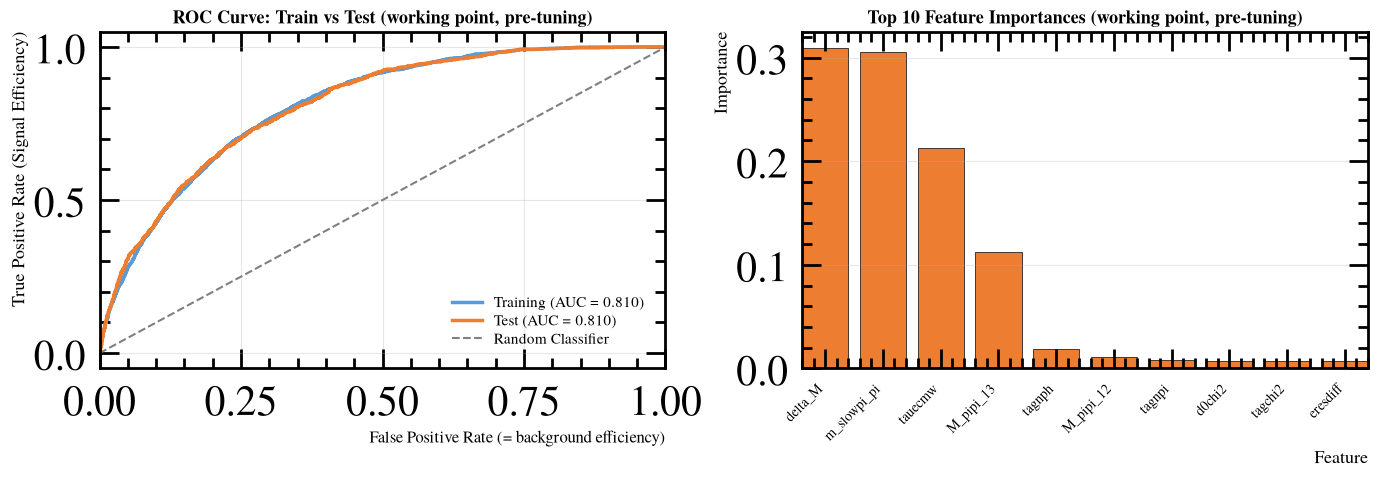

In [17]:
print("Feature importances (selected working point, pre-tuning):")
for feat, imp in sorted(zip(features, bdt.feature_importances_), key=lambda x: -x[1]):
    bar = "#" * int(imp * 50)
    print(f"  {feat:22s} {imp:.4f}  {bar}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(fpr_train, tpr_train, color='#5B9BD5', linewidth=2.5, label=f'Training (AUC = {roc_auc_train:.3f})')
ax.plot(fpr_test, tpr_test, color='#ED7D31', linewidth=2.5, label=f'Test (AUC = {roc_auc_test:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate (= background efficiency)', fontsize=12)
ax.set_ylabel('True Positive Rate (Signal Efficiency)', fontsize=13)
ax.set_title('ROC Curve: Train vs Test (working point, pre-tuning)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1]
importance_sorted_wp = sorted(zip(features, bdt.feature_importances_), key=lambda x: -x[1])
feat_names = [f[0] for f in importance_sorted_wp][:10]
feat_imps = [f[1] for f in importance_sorted_wp][:10]

ax.bar(feat_names, feat_imps, color='#ED7D31', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Feature', fontsize=13)
ax.set_ylabel('Importance', fontsize=13)
ax.set_title('Top 10 Feature Importances (working point, pre-tuning)', fontsize=13, fontweight='bold')
ax.set_xticklabels(feat_names, rotation=45, ha='right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

roc_auc_test_pretuning = roc_auc_test
roc_auc_train_pretuning = roc_auc_train
importance_pretuning = dict(zip(features, bdt.feature_importances_))

## Hyperparameter Optimization

Following feature selection, we perform a targeted hyperparameter search to tune the AdaBoost classifier on the reduced feature set. The optimization focuses on four key hyperparameters that govern model complexity, learning dynamics, and regularization:

- **`n_estimators`** (50–500, step 50): The number of boosting stages. More trees can improve fit but increase runtime and risk overfitting. We cap this at 500 since empirical evidence shows diminishing AUC gains beyond this point for shallow decision trees.

- **`learning_rate`** (0.01–1.0, log-uniform): Shrinkage factor `η` that controls each tree's contribution. Lower rates (`η → 0`) require more estimators but typically yield better generalization, as each tree only makes a small correction to the ensemble:

  $$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

  where `h_m` is the weak learner fitted to the residuals of `F_{m-1}`.

- **`max_depth`** (1–4): Maximum depth of each decision tree weak learner. Shallow trees act as "weak" classifiers, preventing individual trees from overfitting and encouraging diverse, complementary errors across the ensemble.

- **`min_samples_leaf`** (50–2000, log-uniform): Minimum samples required at a leaf node. Larger values produce smoother decision boundaries and regularize against overfitting, particularly important with imbalanced data.

### Search Strategy

To balance thoroughness with computational efficiency:

1. **Subsampling**: The search runs on a stratified subsample of `min(20,000, len(X_train))` rows instead of the full training set, reducing fitting time while preserving the relative ranking of hyperparameter configurations.

2. **Cross-validation**: We use 3-fold stratified CV during search (reduced from 5-fold), trading a small increase in variance for ~40% runtime reduction.

3. **Parallel trials**: Optuna executes `N_TRIALS = 20` configurations in parallel (`n_jobs=-1`) using the TPE (Tree-structured Parzen Estimator) sampler, which intelligently explores the search space by learning from previous evaluations:

   $$p(x|y) = \begin{cases} l(x) & \text{if } y < y^* \\ g(x) & \text{if } y \geq y^* \end{cases}$$

   where `l(x)` models good configurations (low loss) and `g(x)` models poor ones, enabling efficient sampling of promising regions.

### Objective Function

The optimization maximizes the mean ROC-AUC across cross-validation folds:

   $$\text{Objective}(\theta) = \frac{1}{K} \sum_{k=1}^{K} \text{AUC}_k(\theta)$$

where `K = 3` folds and `θ` represents `(n_estimators, learning_rate, max_depth, min_samples_leaf)`. Each fold uses the subsampled training data (`X_search`, `y_search`) with `n_jobs=1` to avoid CPU oversubscription from nested parallelism.



### Final Model Training

After identifying the best hyperparameters from the search (highest CV AUC on the subsample), we **retrain the final AdaBoost model on the full training set** (`X_train`, `y_train`, with all `n_samples` rows). This crucial step ensures the production model benefits from the complete dataset while leveraging the optimized hyperparameters discovered during the efficient search phase.

### Performance Evaluation

The final model's performance is evaluated on both training and test sets:

   $$\text{Train AUC} = \text{AUC}(y_{\text{train}}, F(X_{\text{train}};\theta^*))$$
   $$\text{Test AUC} = \text{AUC}(y_{\text{test}}, F(X_{\text{test}};\theta^*))$$

where `θ*` are the optimized hyperparameters and `F` is the AdaBoost ensemble's decision function. Results are compared against a pre-tuning baseline to quantify the improvement from hyperparameter optimization.


In [18]:
# =========================================================================
# Hyperparameter optimization on the selected working point (faster version)
#
# Speed changes vs. before:
#  - Search runs on a stratified SUBSAMPLE of X_train (SEARCH_SAMPLE_SIZE
#    rows) instead of the full training set - fitting is the dominant cost,
#    and ranking of hyperparameters is usually stable under subsampling.
#  - 3-fold CV during the search instead of 5-fold (one less fold to fit).
#  - n_estimators upper bound lowered to 500 (AdaBoost with shallow trees
#    typically plateaus well before 1200; large boosting counts were doing
#    most of the damage to runtime for little/no AUC gain).
#  - N_TRIALS lowered to 20, with Optuna running trials IN PARALLEL
#    (n_jobs=-1 on study.optimize) instead of relying on parallelizing the
#    inner cross_val_score (n_jobs=1 there now, to avoid oversubscribing
#    CPUs with nested parallelism, which was likely also slowing things down).
#  - The FINAL model (with the best found hyperparameters) is still trained
#    on the FULL X_train/y_train, so the actual production model isn't
#    affected by the subsampling - only the search itself is cheaper.
# =========================================================================
N_TRIALS = 20
SEARCH_SAMPLE_SIZE = min(20000, len(X_train))
cv_hp = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Stratified subsample of the training set, used only for the search
X_search, _, y_search, _ = train_test_split(
    X_train, y_train,
    train_size=SEARCH_SAMPLE_SIZE,
    stratify=y_train,
    random_state=42
)
print(f"Hyperparameter search running on {len(X_search)} rows "
      f"(of {len(X_train)} total training rows)")

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective(trial):
        params = dict(
            n_estimators=trial.suggest_int("n_estimators", 50, 500, step=50),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 1.0, log=True),
            max_depth=trial.suggest_int("max_depth", 1, 4),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 50, 2000, log=True),
        )
        model = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=params["max_depth"],
                                              min_samples_leaf=params["min_samples_leaf"]),
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            random_state=42
        )
        scores = cross_val_score(model, X_search, y_search, cv=cv_hp,
                                  scoring='roc_auc', n_jobs=1)
        return scores.mean()

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=N_TRIALS, n_jobs=-1, show_progress_bar=False)

    best_params_raw = study.best_params
    best_cv_auc = study.best_value
    print(f"Optuna: {N_TRIALS} trials, best CV AUC (on subsample) = {best_cv_auc:.4f}")
    print(f"Best params: {best_params_raw}")

    best_params = dict(
        n_estimators=best_params_raw["n_estimators"],
        learning_rate=best_params_raw["learning_rate"],
        max_depth=best_params_raw["max_depth"],
        min_samples_leaf=best_params_raw["min_samples_leaf"],
    )

except ImportError:
    print("Optuna not installed - falling back to RandomizedSearchCV.")
    from sklearn.model_selection import RandomizedSearchCV
    from scipy.stats import loguniform, randint

    param_distributions = {
        "n_estimators": randint(50, 500),
        "learning_rate": loguniform(0.01, 1.0),
        "estimator__max_depth": randint(1, 5),
        "estimator__min_samples_leaf": randint(50, 2000),
    }
    base_model = AdaBoostClassifier(estimator=DecisionTreeClassifier(), random_state=42)
    search = RandomizedSearchCV(
        base_model, param_distributions, n_iter=N_TRIALS, cv=cv_hp,
        scoring='roc_auc', random_state=42, n_jobs=-1
    )
    search.fit(X_search, y_search)
    best_cv_auc = search.best_score_
    print(f"RandomizedSearchCV: {N_TRIALS} iterations, best CV AUC (on subsample) = {best_cv_auc:.4f}")
    print(f"Best params: {search.best_params_}")

    best_params = dict(
        n_estimators=search.best_params_["n_estimators"],
        learning_rate=search.best_params_["learning_rate"],
        max_depth=search.best_params_["estimator__max_depth"],
        min_samples_leaf=search.best_params_["estimator__min_samples_leaf"],
    )

# Final model: trained on the FULL training set with the best hyperparameters found
bdt = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=best_params["max_depth"],
                                      min_samples_leaf=best_params["min_samples_leaf"]),
    n_estimators=best_params["n_estimators"],
    learning_rate=best_params["learning_rate"],
    random_state=42
)
bdt.fit(X_train, y_train)

y_score_train = bdt.decision_function(X_train)
y_score_test = bdt.decision_function(X_test)

fpr_train, tpr_train, _ = roc_curve(y_train, y_score_train)
fpr_test, tpr_test, _ = roc_curve(y_test, y_score_test)
roc_auc_train = auc(fpr_train, tpr_train)
roc_auc_test = auc(fpr_test, tpr_test)

print(f"\nTuned model (full training set): Train AUC = {roc_auc_train:.4f}, Test AUC = {roc_auc_test:.4f}")
print(f"Pre-tuning (for comparison):     Train AUC = {roc_auc_train_pretuning:.4f}, "
      f"Test AUC = {roc_auc_test_pretuning:.4f}")

Hyperparameter search running on 20000 rows (of 77882 total training rows)
Optuna: 20 trials, best CV AUC (on subsample) = 0.7845
Best params: {'n_estimators': 400, 'learning_rate': 0.4105966884412476, 'max_depth': 2, 'min_samples_leaf': 408}

Tuned model (full training set): Train AUC = 0.8132, Test AUC = 0.8125
Pre-tuning (for comparison):     Train AUC = 0.8097, Test AUC = 0.8098


## PLOT: ROC Curve, BDT Score Distributions, and Feature Importances -- After Hyperparameter Tuning

Same three diagnostics as before (ROC curve, feature importances) plus the
BDT score-distribution overtraining check, now for the **tuned** model, so
the improvement (or lack of it) from hyperparameter optimization and any
change in the feature-importance ranking are both visible directly against
the pre-tuning working-point numbers stored above.

Feature importances (tuned model):
  delta_M                0.2702  #############
  tauecmw                0.2530  ############
  m_slowpi_pi            0.2325  ###########
  M_pipi_13              0.1598  #######
  M_pipi_12              0.0210  #
  tagnph                 0.0205  #
  eresdiff               0.0133  
  tagchi2                0.0105  
  d0chi2                 0.0099  
  tagnpi                 0.0092  


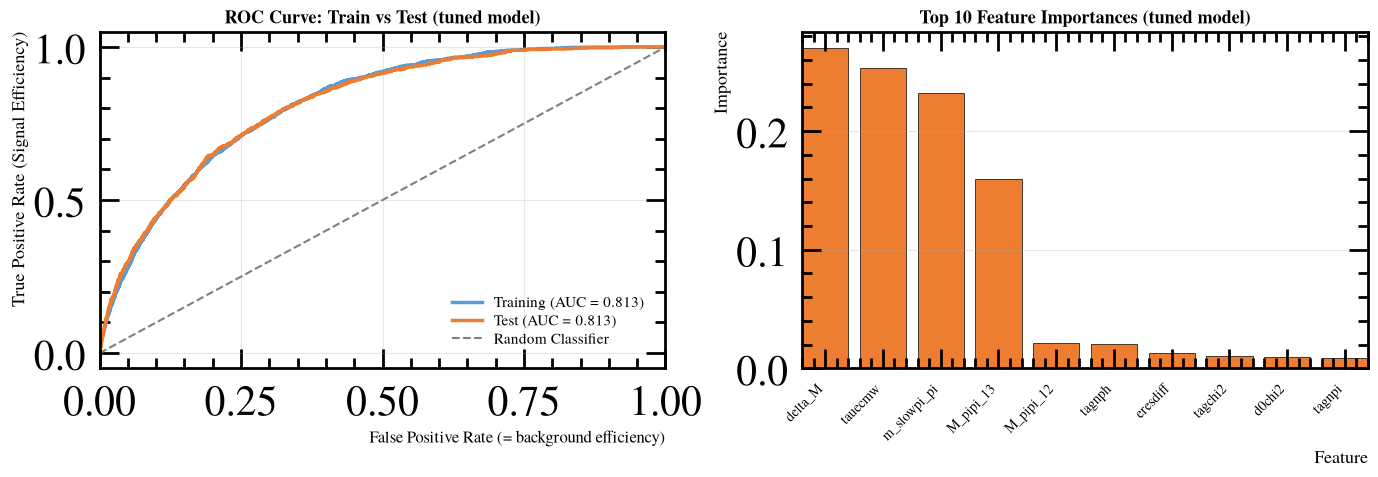

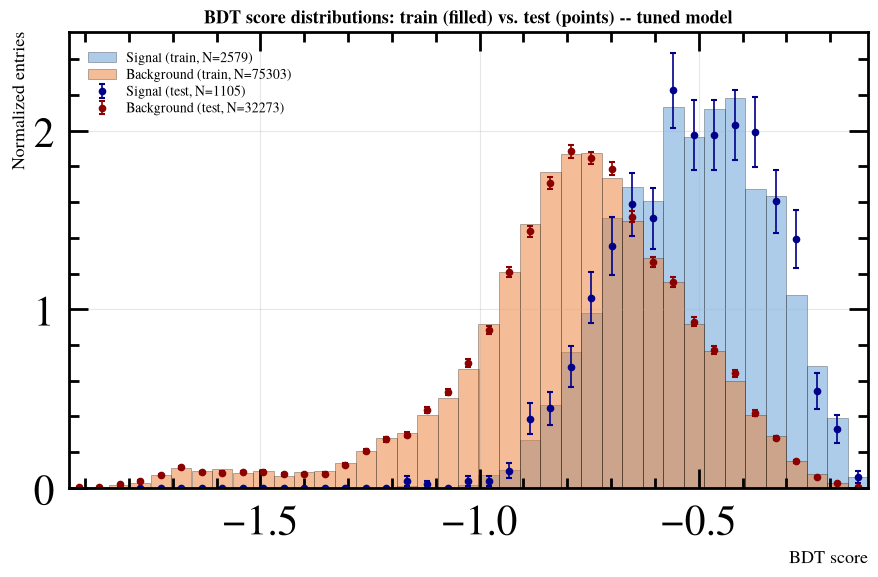

Overtraining check (KS test, train vs. test score distributions, tuned model):
  Signal:     KS = 0.0240, p-value = 0.7532
  Background: KS = 0.0059, p-value = 0.4075

BEFORE vs. AFTER HYPERPARAMETER TUNING
Test AUC  pre-tuning: 0.8098
Test AUC post-tuning: 0.8125  (delta = +0.0028)

Feature                 Rank (pre)  Rank (post)  Imp (pre)  Imp (post)
delta_M                          1            1     0.3095      0.2702
tauecmw                          3            2     0.2131      0.2530
m_slowpi_pi                      2            3     0.3056      0.2325
M_pipi_13                        4            4     0.1124      0.1598
M_pipi_12                        6            5     0.0107      0.0210
tagnph                           5            6     0.0188      0.0205
eresdiff                        10            7     0.0071      0.0133
tagchi2                          9            8     0.0073      0.0105
d0chi2                           8            9     0.0074      0.0099
tagnp

In [19]:
print("Feature importances (tuned model):")
for feat, imp in sorted(zip(features, bdt.feature_importances_), key=lambda x: -x[1]):
    bar = "#" * int(imp * 50)
    print(f"  {feat:22s} {imp:.4f}  {bar}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(fpr_train, tpr_train, color='#5B9BD5', linewidth=2.5, label=f'Training (AUC = {roc_auc_train:.3f})')
ax.plot(fpr_test, tpr_test, color='#ED7D31', linewidth=2.5, label=f'Test (AUC = {roc_auc_test:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate (= background efficiency)', fontsize=12)
ax.set_ylabel('True Positive Rate (Signal Efficiency)', fontsize=13)
ax.set_title('ROC Curve: Train vs Test (tuned model)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1]
importance_sorted_tuned = sorted(zip(features, bdt.feature_importances_), key=lambda x: -x[1])
feat_names = [f[0] for f in importance_sorted_tuned][:10]
feat_imps = [f[1] for f in importance_sorted_tuned][:10]
ax.bar(feat_names, feat_imps, color='#ED7D31', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Feature', fontsize=13)
ax.set_ylabel('Importance', fontsize=13)
ax.set_title('Top 10 Feature Importances (tuned model)', fontsize=13, fontweight='bold')
ax.set_xticklabels(feat_names, rotation=45, ha='right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

bins = np.linspace(
    min(y_score_train.min(), y_score_test.min()),
    max(y_score_train.max(), y_score_test.max()),
    40
)
train_sig = y_score_train[y_train == 1]
train_bkg = y_score_train[y_train == 0]
test_sig = y_score_test[y_test == 1]
test_bkg = y_score_test[y_test == 0]

fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(train_sig, bins=bins, density=True, alpha=0.5, color='#5B9BD5',
        edgecolor='black', linewidth=0.4, label=f'Signal (train, N={len(train_sig)})')
ax.hist(train_bkg, bins=bins, density=True, alpha=0.5, color='#ED7D31',
        edgecolor='black', linewidth=0.4, label=f'Background (train, N={len(train_bkg)})')

def hist_points(vals, bins):
    counts, edges = np.histogram(vals, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    width = edges[1] - edges[0]
    norm = counts.sum() * width
    density = counts / norm if norm > 0 else counts * 0.0
    density_err = np.sqrt(counts) / norm if norm > 0 else counts * 0.0
    return centers, density, density_err

xc, yc, yerr = hist_points(test_sig, bins)
ax.errorbar(xc, yc, yerr=yerr, fmt='o', color='darkblue', markersize=4,
            elinewidth=1.2, capsize=2, label=f'Signal (test, N={len(test_sig)})')
xc, yc, yerr = hist_points(test_bkg, bins)
ax.errorbar(xc, yc, yerr=yerr, fmt='o', color='darkred', markersize=4,
            elinewidth=1.2, capsize=2, label=f'Background (test, N={len(test_bkg)})')

ax.set_xlabel('BDT score', fontsize=13)
ax.set_ylabel('Normalized entries', fontsize=13)
ax.set_title('BDT score distributions: train (filled) vs. test (points) -- tuned model', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ks_sig_stat, ks_sig_p = ks_2samp(train_sig, test_sig)
ks_bkg_stat, ks_bkg_p = ks_2samp(train_bkg, test_bkg)
print("Overtraining check (KS test, train vs. test score distributions, tuned model):")
print(f"  Signal:     KS = {ks_sig_stat:.4f}, p-value = {ks_sig_p:.4f}")
print(f"  Background: KS = {ks_bkg_stat:.4f}, p-value = {ks_bkg_p:.4f}")

print()
print("="*60)
print("BEFORE vs. AFTER HYPERPARAMETER TUNING")
print("="*60)
print(f"Test AUC  pre-tuning: {roc_auc_test_pretuning:.4f}")
print(f"Test AUC post-tuning: {roc_auc_test:.4f}  (delta = {roc_auc_test - roc_auc_test_pretuning:+.4f})")
print()
print(f"{'Feature':22s} {'Rank (pre)':>11s} {'Rank (post)':>12s} {'Imp (pre)':>10s} {'Imp (post)':>11s}")
rank_pre = {f: i+1 for i, (f, _) in enumerate(sorted(importance_pretuning.items(), key=lambda x: -x[1]))}
importance_posttuning = dict(zip(features, bdt.feature_importances_))
rank_post = {f: i+1 for i, (f, _) in enumerate(sorted(importance_posttuning.items(), key=lambda x: -x[1]))}
for f in sorted(features, key=lambda f: rank_post[f]):
    print(f"{f:22s} {rank_pre[f]:11d} {rank_post[f]:12d} "
          f"{importance_pretuning[f]:10.4f} {importance_posttuning[f]:11.4f}")

roc_auc = roc_auc_test

## FPR vs. Background Efficiency/Rejection 

By construction of the ROC curve, the **False Positive Rate (FPR)** *is*
the background efficiency: `FPR = B_selected / B_total` at a given
threshold, i.e. the fraction of background that survives the cut. The
**background rejection** is simply its complement:

$$\text{Rejection} = 1 - \text{FPR} = 1 - \varepsilon_{bkg}$$

The cell below makes this connection explicit and plots background
rejection alongside signal efficiency as a function of the BDT threshold,
using the same threshold scan as the Punzi optimization further down.

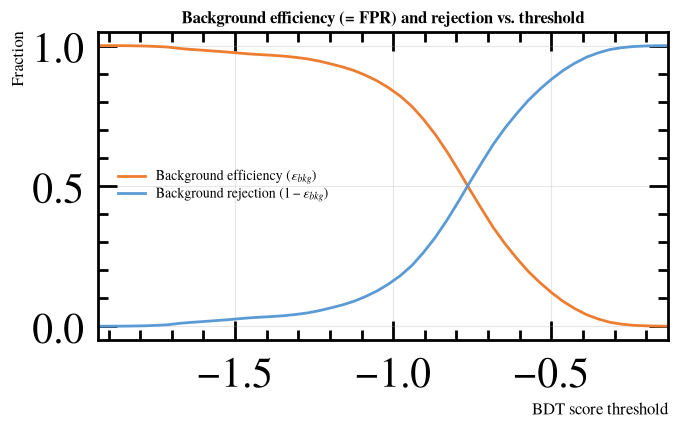

Sanity check: background efficiency at threshold scan matches FPR from roc_curve() (both are B_selected / B_total at a matching threshold).


In [20]:
# explicit FPR <-> background efficiency/rejection check
thr_check = np.linspace(y_score_test.min(), y_score_test.max(), 50)
bkg_eff_check = []
for t in thr_check:
    passed = y_score_test > t
    eff_bkg = np.sum(passed & (y_test == 0)) / np.sum(y_test == 0)
    bkg_eff_check.append(eff_bkg)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thr_check, bkg_eff_check, color='#ED7D31', linewidth=2, label=r'Background efficiency ($\varepsilon_{bkg}$)')
ax.plot(thr_check, 1 - np.array(bkg_eff_check), color='#5B9BD5', linewidth=2, label=r'Background rejection ($1-\varepsilon_{bkg}$)')
ax.set_xlabel('BDT score threshold', fontsize=12)
ax.set_ylabel('Fraction', fontsize=12)
ax.set_title('Background efficiency (= FPR) and rejection vs. threshold', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Sanity check: background efficiency at threshold scan matches FPR from roc_curve() "
      "(both are B_selected / B_total at a matching threshold).")


STEP 8: PUNZI OPTIMIZATION
Optimal Punzi threshold: -0.5837
Signal efficiency at optimum: 66.7%
Background efficiency (= FPR) at optimum: 21.0%


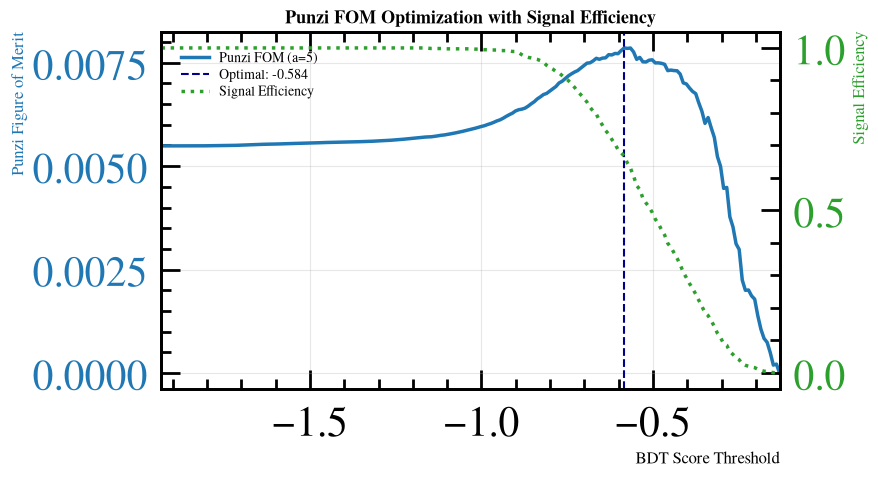

In [21]:
print("="*60)
print("STEP 8: PUNZI OPTIMIZATION")
print("="*60)

# Scan thresholds
thresholds = np.linspace(y_score_test.min(), y_score_test.max(), 200)
signal_efficiency = []
background_efficiency = []
punzi_fom = []

total_signal = np.sum(y_test == 1)
total_background = np.sum(y_test == 0)
a = 5   # Punzi 'a' parameter (target discovery significance)

for t in thresholds:
    passed = y_score_test > t
    S = np.sum(passed & (y_test == 1))
    B = np.sum(passed & (y_test == 0))
    eff_sig = S / total_signal if total_signal > 0 else 0
    eff_bkg = B / total_background if total_background > 0 else 0   
    signal_efficiency.append(eff_sig)
    background_efficiency.append(eff_bkg)
    punzi_fom.append(eff_sig / (a/2 + np.sqrt(B)) if B >= 0 else 0)

best_idx = np.argmax(punzi_fom)
best_threshold = thresholds[best_idx]
print(f"Optimal Punzi threshold: {best_threshold:.4f}")
print(f"Signal efficiency at optimum: {signal_efficiency[best_idx]*100:.1f}%")
print(f"Background efficiency (= FPR) at optimum: {background_efficiency[best_idx]*100:.1f}%")

fig, ax1 = plt.subplots(figsize=(9, 5))

color = 'tab:blue'
ax1.set_xlabel('BDT Score Threshold', fontsize=12)
ax1.set_ylabel('Punzi Figure of Merit', color=color, fontsize=12)
ax1.plot(thresholds, punzi_fom, color=color, linewidth=2.5, label=f'Punzi FOM (a={a})')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axvline(best_threshold, color='darkblue', linestyle='--', linewidth=1.5,
            label=f'Optimal: {best_threshold:.3f}')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Signal Efficiency', color=color, fontsize=12)
ax2.plot(thresholds, signal_efficiency, color=color, linestyle=':', linewidth=2.5, label='Signal Efficiency')
ax2.tick_params(axis='y', labelcolor=color)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title('Punzi FOM Optimization with Signal Efficiency', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



In [64]:
print("="*60)
print("STEP 9: SELECTION & MASS EXTRACTION")
print("="*60)

all_scores = bdt.decision_function(X)
df_all.loc[X.index, 'bdt_score'] = all_scores


best_threshold = -0.47 # --------------------------------------- CHANGE THIS VALUE - SEE PUNZI FOM PLOT
bdt_selection = df_all['bdt_score'] >= best_threshold
selected_data = df_all[bdt_selection]

mass_var = "tagmbc"
n_bins = 40
mass_range = (5.20, 5.30)

selected_mass = selected_data[mass_var].dropna()
counts_sel, bins_sel = np.histogram(selected_mass, bins=n_bins, range=mass_range)
bin_centers = 0.5 * (bins_sel[:-1] + bins_sel[1:])
bin_width = bins_sel[1] - bins_sel[0]

all_mass = df_all[mass_var].dropna()

print(f"Selected events: {len(selected_mass)}")
print(f"Total counts in histogram: {counts_sel.sum()}")

if counts_sel.sum() == 0:
    raise ValueError("No events survive the BDT selection in the fit window - "
                      "loosen best_threshold or check mass_var/mass_range.")


STEP 9: SELECTION & MASS EXTRACTION
Selected events: 11695
Total counts in histogram: 11695


In [65]:
def signal_plus_bkg(x, n_sig, mu, sigma, n_bkg, chi, m0):
    sig_pdf = norm.pdf(x, loc=mu, scale=sigma)
    bkg_pdf = argus.pdf(x, chi, loc=0, scale=m0)
    return n_sig * sig_pdf * bin_width + n_bkg * bkg_pdf * bin_width

total_counts = counts_sel.sum()
p0 = [total_counts*0.2, 5.279, 0.003, total_counts*0.8, 3.0, mass_range[1]]
bounds = (
    [0, mass_range[0], 0.0005, 0, 0.1, mass_range[1] - 0.01],
    [total_counts*2, mass_range[1], 0.02, total_counts*2, 15, mass_range[1] + 0.01]
)

popt, pcov = curve_fit(signal_plus_bkg, bin_centers, counts_sel, p0=p0, bounds=bounds, maxfev=20000)
n_sig_fit, mu_fit, sigma_fit, n_bkg_fit, chi_fit, m0_fit = popt
errs = np.sqrt(np.diag(pcov))
n_sig_err, mu_err, sigma_err, n_bkg_err, chi_err, m0_err = errs
significance = n_sig_fit / n_sig_err if n_sig_err > 0 else float('nan')

print(f"Signal yield  = {n_sig_fit:.1f} +/- {n_sig_err:.1f}")
print(f"Peak (mu)     = {mu_fit:.5f} +/- {mu_err:.5f} GeV")
print(f"Sigma         = {abs(sigma_fit):.5f} +/- {sigma_err:.5f} GeV")
print(f"Background N  = {n_bkg_fit:.1f} +/- {n_bkg_err:.1f}")
print(f"Significance  = {significance:.2f} sigma")


Signal yield  = 608.6 +/- 173.8
Peak (mu)     = 5.27744 +/- 0.00119 GeV
Sigma         = 0.00597 +/- 0.00136 GeV
Background N  = 23390.0 +/- 1345.4
Significance  = 3.50 sigma


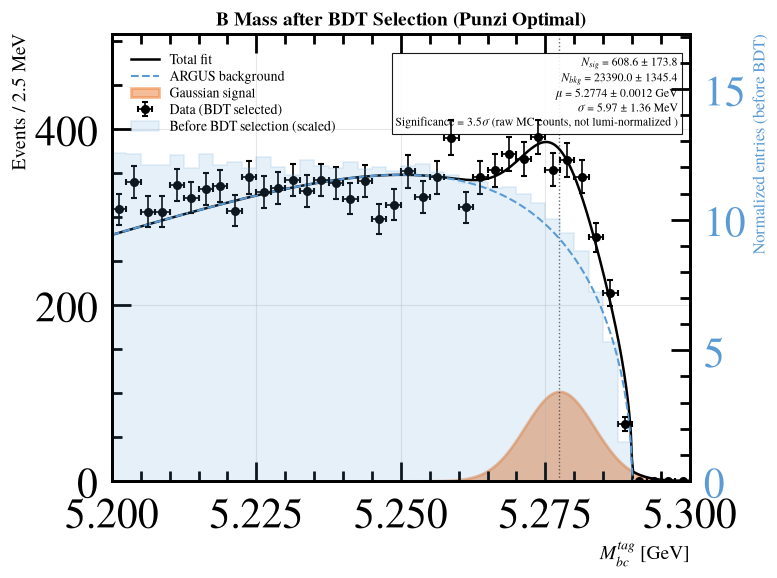

SUMMARY
BDT AUC: 0.813
Optimal Punzi threshold: -0.4700
Signal efficiency: 66.7%
Selected events: 11695
Signal yield: 608.6 +/- 173.8
Significance: 3.5 sigma



In [66]:
fig, ax = plt.subplots(figsize=(8, 6))

# "Before BDT selection" plotted on a secondary (right-hand) y-axis, since
# it's density-normalized while the main axis shows raw per-bin counts —
# the two scales don't match, so a twin axis avoids a misleading overlay.
ax2 = ax.twinx()
ax2.hist(all_mass, bins=bins_sel, histtype='stepfilled',
         color='#5B9BD5', alpha=0.15, edgecolor='#5B9BD5', linewidth=1.2,
         density=True,
         label='Before BDT selection (scaled)')
ax2.set_ylabel('Normalized entries (before BDT)', fontsize=12, color='#5B9BD5')
ax2.tick_params(axis='y', labelcolor='#5B9BD5')
ax2.set_ylim(0, ax2.get_ylim()[1] * 1.3)

x_err = bin_width / 2
ax.errorbar(bin_centers, counts_sel, yerr=np.sqrt(counts_sel + 1e-10), xerr=x_err,
            fmt='o', color='black', markersize=5, elinewidth=1.2, capsize=2,
            label='Data (BDT selected)', zorder=5)

x_fit = np.linspace(mass_range[0], mass_range[1], 500)
sig_curve = n_sig_fit * norm.pdf(x_fit, loc=mu_fit, scale=sigma_fit) * bin_width
bkg_curve = n_bkg_fit * argus.pdf(x_fit, chi_fit, loc=0, scale=m0_fit) * bin_width
total_curve = sig_curve + bkg_curve

ax.plot(x_fit, total_curve, color='black', linewidth=1.8, label='Total fit')
ax.plot(x_fit, bkg_curve, color='#5B9BD5', linewidth=1.5, linestyle='--', label='ARGUS background')
ax.fill_between(x_fit, 0, sig_curve, color='#ED7D31', alpha=0.5, label='Gaussian signal')
ax.axvline(mu_fit, color='black', linestyle=':', linewidth=1.0, alpha=0.6)

ax.set_xlim(mass_range)
ax.set_ylim(0, max(counts_sel.max(), total_curve.max()) * 1.3)
ax.set_xlabel(r'$M_{bc}^{tag}$ [GeV]', fontsize=14)
ax.set_ylabel(f'Events / {bin_width*1000:.1f} MeV', fontsize=14)
ax.set_title('B Mass after BDT Selection (Punzi Optimal)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# combine legends from both axes into one
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

stats_text = (
    f'$N_{{sig}}$ = {n_sig_fit:.1f} $\pm$ {n_sig_err:.1f}\n'
    f'$N_{{bkg}}$ = {n_bkg_fit:.1f} $\pm$ {n_bkg_err:.1f}\n'
    f'$\mu$ = {mu_fit:.4f} $\pm$ {mu_err:.4f} GeV\n'
    f'$\sigma$ = {sigma_fit*1000:.2f} $\pm$ {sigma_err*1000:.2f} MeV\n'
    f'Significance = {significance:.1f}$\sigma$ (raw MC counts, not lumi-normalized )'
)
ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, fontsize=8.5,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', linewidth=0.8, alpha=0.9))

plt.tight_layout()
plt.show()

print("="*60)
print("SUMMARY")
print("="*60)
print(f"BDT AUC: {roc_auc:.3f}")
print(f"Optimal Punzi threshold: {best_threshold:.4f}")
print(f"Signal efficiency: {signal_efficiency[best_idx]*100:.1f}%")
print(f"Selected events: {len(selected_data)}")
print(f"Signal yield: {n_sig_fit:.1f} +/- {n_sig_err:.1f}")
print(f"Significance: {significance:.1f} sigma")
print()



N_inject=  304.3  mean_fit= 263.38  bias=-40.91  pull_mean=-0.776  pull_std=1.512  (failed fits: 0/300)
N_inject=  456.4  mean_fit= 426.02  bias=-30.42  pull_mean=-0.422  pull_std=1.090  (failed fits: 0/300)
N_inject=  608.6  mean_fit= 579.76  bias=-28.83  pull_mean=-0.365  pull_std=1.021  (failed fits: 0/300)
N_inject=  760.7  mean_fit= 714.09  bias=-46.64  pull_mean=-0.491  pull_std=0.948  (failed fits: 0/300)
N_inject=  912.9  mean_fit= 872.68  bias=-40.19  pull_mean=-0.419  pull_std=0.901  (failed fits: 0/300)
N_inject= 1217.2  mean_fit=1167.66  bias=-49.50  pull_mean=-0.470  pull_std=0.904  (failed fits: 0/300)


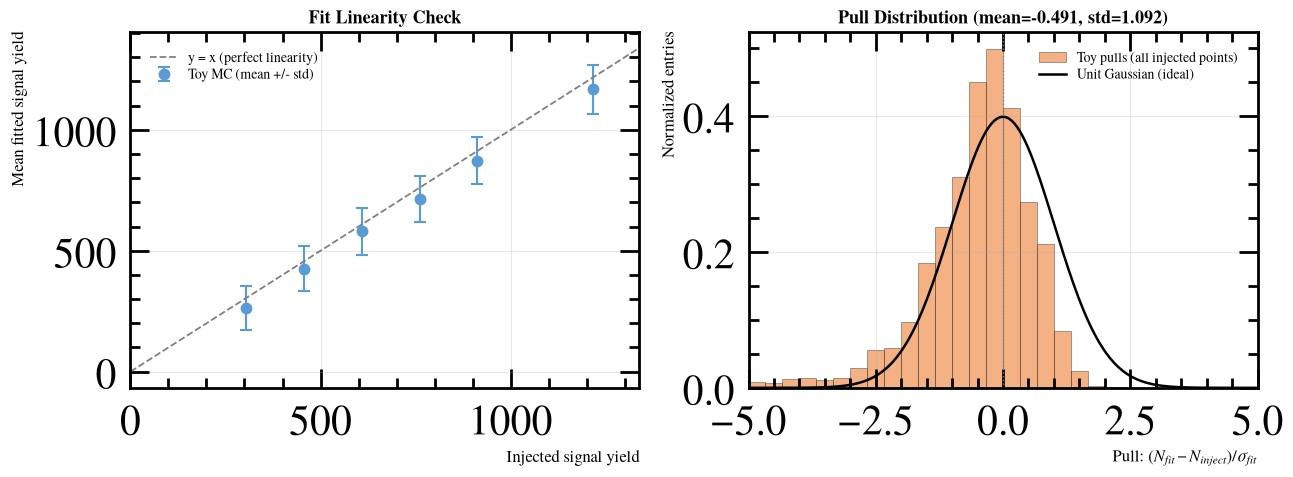

In [67]:
# =============================================================================
# FIT VALIDATION: Toy MC linearity / pull test
#
# Uses the already-fitted PDF shapes (Gaussian signal + ARGUS background,
# from the fit above) as truth templates. For a range of injected signal
# yields, generate many Poisson-fluctuated toy datasets, refit each with the
# same procedure, and check:
#   - Linearity: mean fitted yield vs. injected yield should lie on y = x
#   - Pulls: (fitted - injected) / fit_error should be centered at 0 with
#     width 1, for a well-calibrated, unbiased fit
# Background yield is held fixed at n_bkg_fit for each toy (single-parameter
# linearity test on the signal yield, the standard simplified version of
# this check).
# =============================================================================
rng = np.random.default_rng(42)

n_toys_per_point = 300
injected_signal_yields = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 2.0]) * n_sig_fit

def generate_toy_counts(n_sig_inject, n_bkg_fixed):
    expected = signal_plus_bkg(bin_centers, n_sig_inject, mu_fit, sigma_fit,
                                n_bkg_fixed, chi_fit, m0_fit)
    expected = np.clip(expected, 1e-6, None)  # guard against negative/zero means
    return rng.poisson(expected)

results = []
for n_inject in injected_signal_yields:
    fitted_yields = []
    fitted_errs = []
    n_failed = 0
    for _ in range(n_toys_per_point):
        toy_counts = generate_toy_counts(n_inject, n_bkg_fit)
        try:
            popt_toy, pcov_toy = curve_fit(
                signal_plus_bkg, bin_centers, toy_counts,
                p0=[n_inject, mu_fit, sigma_fit, n_bkg_fit, chi_fit, m0_fit],
                bounds=bounds, maxfev=20000
            )
            n_sig_toy = popt_toy[0]
            n_sig_err_toy = np.sqrt(pcov_toy[0, 0])
            if n_sig_err_toy > 0 and np.isfinite(n_sig_err_toy):
                fitted_yields.append(n_sig_toy)
                fitted_errs.append(n_sig_err_toy)
            else:
                n_failed += 1
        except RuntimeError:
            n_failed += 1

    fitted_yields = np.array(fitted_yields)
    fitted_errs = np.array(fitted_errs)
    pulls = (fitted_yields - n_inject) / fitted_errs

    results.append({
        "n_injected": n_inject,
        "mean_fitted": fitted_yields.mean(),
        "std_fitted": fitted_yields.std(),
        "bias": fitted_yields.mean() - n_inject,
        "pull_mean": pulls.mean(),
        "pull_std": pulls.std(),
        "n_failed": n_failed,
        "n_success": len(fitted_yields),
        "pulls": pulls,
    })
    print(f"N_inject={n_inject:7.1f}  mean_fit={fitted_yields.mean():7.2f}  "
          f"bias={fitted_yields.mean()-n_inject:+6.2f}  "
          f"pull_mean={pulls.mean():+.3f}  pull_std={pulls.std():.3f}  "
          f"(failed fits: {n_failed}/{n_toys_per_point})")

# -------------------------------------------------------------------------
# Plot 1: Linearity check (mean fitted vs. injected, with y = x reference)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
n_inj_arr = np.array([r["n_injected"] for r in results])
mean_fit_arr = np.array([r["mean_fitted"] for r in results])
std_fit_arr = np.array([r["std_fitted"] for r in results])

ax.errorbar(n_inj_arr, mean_fit_arr, yerr=std_fit_arr, fmt='o', color='#5B9BD5',
            markersize=7, capsize=4, elinewidth=1.5, label='Toy MC (mean +/- std)')
lims = [0, max(n_inj_arr.max(), mean_fit_arr.max()) * 1.1]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1.3, label='y = x (perfect linearity)')
ax.set_xlabel('Injected signal yield', fontsize=12)
ax.set_ylabel('Mean fitted signal yield', fontsize=12)
ax.set_title('Fit Linearity Check', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# -------------------------------------------------------------------------
# Plot 2: Pull distribution, combined across all injected points
# -------------------------------------------------------------------------
ax = axes[1]
all_pulls = np.concatenate([r["pulls"] for r in results])
ax.hist(all_pulls, bins=30, range=(-5, 5), density=True, color='#ED7D31',
        alpha=0.6, edgecolor='black', linewidth=0.4, label='Toy pulls (all injected points)')
x_gauss = np.linspace(-5, 5, 200)
ax.plot(x_gauss, norm.pdf(x_gauss, loc=0, scale=1), color='black', linewidth=1.8,
        label='Unit Gaussian (ideal)')
ax.axvline(0, color='gray', linestyle=':', linewidth=1.0)
ax.set_xlabel(r'Pull: $(N_{fit} - N_{inject}) / \sigma_{fit}$', fontsize=12)
ax.set_ylabel('Normalized entries', fontsize=12)
ax.set_title(f'Pull Distribution (mean={all_pulls.mean():+.3f}, std={all_pulls.std():.3f})',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Before BDT: N=111260
After BDT:  N=11695


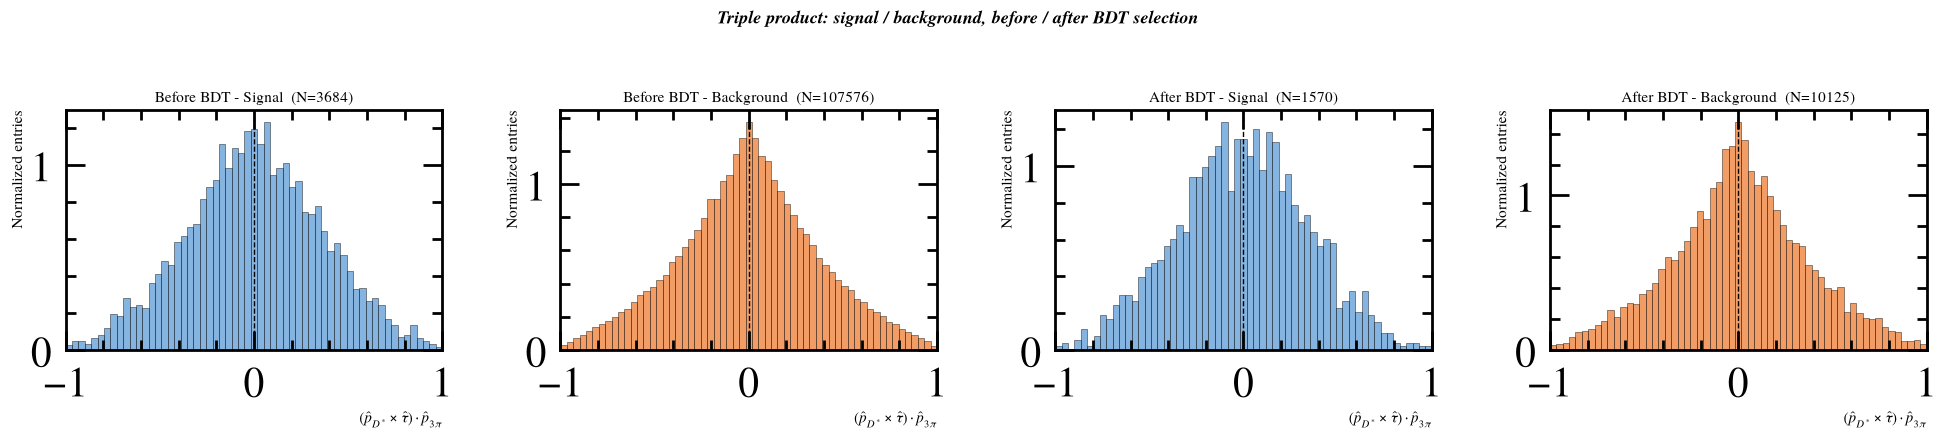

Group                              N    N(+)    N(-)          Asymmetry
Before BDT - Signal             3684    1847    1837   0.0027 +/- 0.0165
Before BDT - Background       107576   54057   53519   0.0050 +/- 0.0030
After BDT - Signal              1570     772     798  -0.0166 +/- 0.0252
After BDT - Background         10125    5138    4987   0.0149 +/- 0.0099


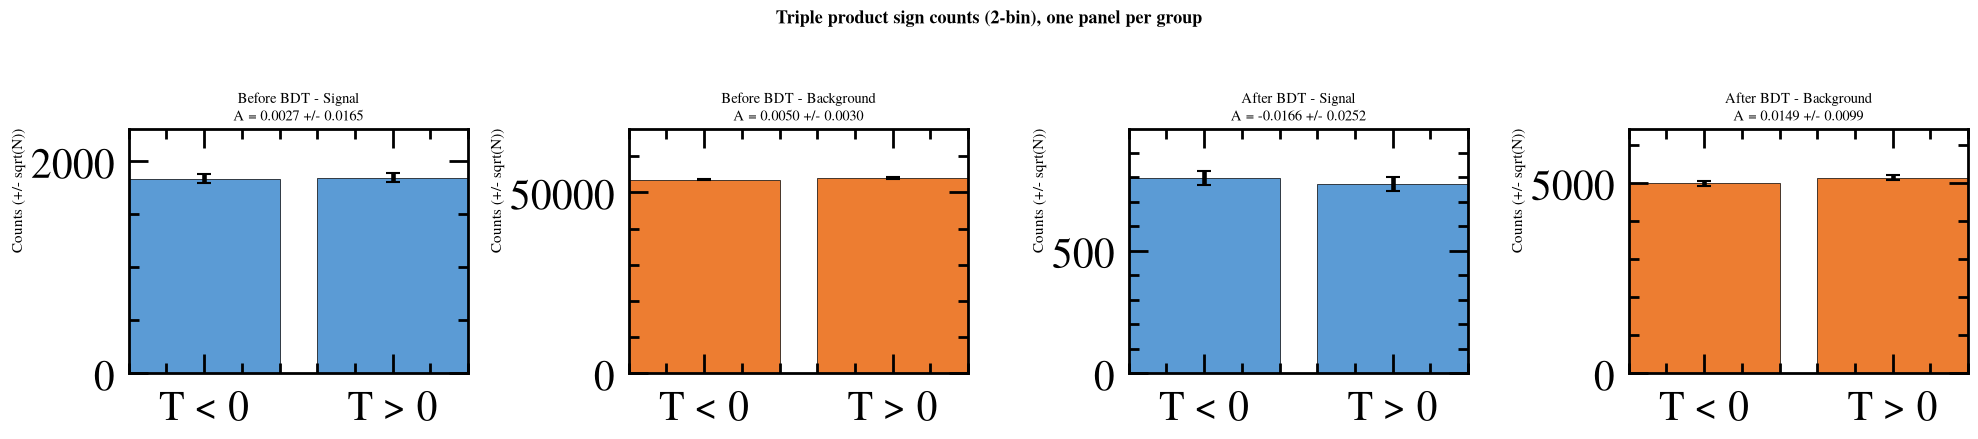

In [68]:
plt.style.use(hep.style.LHCb2)

tp_all = df_all["triple_product_reco"].dropna()
tp_all = tp_all[np.isfinite(tp_all)]

tp_selected = df_all.loc[df_all["bdt_score"] >= best_threshold, "triple_product_reco"].dropna()
tp_selected = tp_selected[np.isfinite(tp_selected)]

sig_mask_all = df_all.loc[tp_all.index, "label"] == 1
bkg_mask_all = df_all.loc[tp_all.index, "label"] == 0
sig_mask_sel = df_all.loc[tp_selected.index, "label"] == 1
bkg_mask_sel = df_all.loc[tp_selected.index, "label"] == 0

groups = [
    ("Before BDT - Signal",     tp_all[sig_mask_all],      '#5B9BD5'),
    ("Before BDT - Background", tp_all[bkg_mask_all],      '#ED7D31'),
    ("After BDT - Signal",      tp_selected[sig_mask_sel], '#5B9BD5'),
    ("After BDT - Background",  tp_selected[bkg_mask_sel], '#ED7D31'),
]

print(f"Before BDT: N={len(tp_all)}")
print(f"After BDT:  N={len(tp_selected)}")

bins = np.linspace(-1, 1, 60)
fig, axes = plt.subplots(1, 4, figsize=(20, 4.2), sharey=False)

for ax, (title, tp, color) in zip(axes, groups):
    ax.hist(tp, bins=bins, alpha=0.75, color=color,
            edgecolor='black', linewidth=0.4, density=True)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.0)
    ax.set_xlabel(r"$(\hat{p}_{D^*} \times \hat{\tau}) \cdot \hat{p}_{3\pi}$", fontsize=11)
    ax.set_ylabel("Normalized entries", fontsize=11)
    ax.set_title(f"{title}  (N={len(tp)})", fontsize=11)

fig.suptitle("Triple product: signal / background, before / after BDT selection",
             fontsize=13, style="italic", fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# 2-bin bar chart 
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))

print(f"{'Group':28s} {'N':>7s} {'N(+)':>7s} {'N(-)':>7s} {'Asymmetry':>18s}")
for ax, (title, tp, color) in zip(axes, groups):
    n_pos = int((tp > 0).sum())
    n_neg = int((tp < 0).sum())
    A, A_err = asymmetry_with_error(n_pos, n_neg)

    ax.bar(['T < 0', 'T > 0'], [n_neg, n_pos],
           yerr=[np.sqrt(n_neg), np.sqrt(n_pos)], capsize=5,
           color=color, edgecolor='black', linewidth=0.5)
    ax.set_ylim(0, max(n_neg, n_pos) * 1.25)
    ax.set_ylabel('Counts (+/- sqrt(N))', fontsize=11)
    ax.set_title(f"{title}\nA = {A:.4f} +/- {A_err:.4f}", fontsize=10.5)

    print(f"{title:28s} {len(tp):7d} {n_pos:7d} {n_neg:7d} "
          f"{A:8.4f} +/- {A_err:.4f}")

fig.suptitle("Triple product sign counts (2-bin), one panel per group",
             fontsize=13, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


# Forward/Backward Tau Asymmetry Analysis

## Definition

The tau polar angle ($\theta_\tau$) is defined relative to the beam axis
(z-axis):

$$\cos\theta_{\tau} = \frac{p_z^{\tau}}{|\vec{p}_{\tau}|}$$

where $\vec{p}_{\tau}$ is the tau momentum direction from the interaction
point (IP) to the tau decay vertex.

---

## Event Classification

| Region | Condition | Description |
|--------|-----------|--------------|
| **Forward** | $\cos\theta_{\tau} > 0$ | Tau emitted in the forward direction |
| **Backward** | $\cos\theta_{\tau} < 0$ | Tau emitted in the backward direction |

---

## Asymmetries Calculated

### 1. Forward-Backward Asymmetry ($A_{FB}$)

$$A_{FB} = \frac{N_{\text{forward}} - N_{\text{backward}}}{N_{\text{forward}} + N_{\text{backward}}}$$

### 2. Triple Product Asymmetry ($A_T$)

$$A_T = \frac{N(\mathcal{T} > 0) - N(\mathcal{T} < 0)}{N(\mathcal{T} > 0) + N(\mathcal{T} < 0)}$$

Calculated separately for forward ($A_T^{fwd}$) and backward ($A_T^{bwd}$)
events.

---

## A Note on Frames 

The two implementations below use:

1. **Lab-frame vertex direction** (`tau_cos_theta`): a purely geometric angle
   from the IP to the tau decay vertex -- not a Lorentz-transformed quantity,
   so it is *not* the tau direction in any particular kinematic frame.
2. **CMS-of-Upsilon(4S) momentum direction** (`tau_cos_theta_CMS`): the tau
   momentum direction as reconstructed directly in the CMS frame of the
   Upsilon(4S), i.e. the standard "CMS" frame already used throughout this
   analysis for other variables (`*cms` branches).



FORWARD/BACKWARD TAU ASYMMETRY (lab-frame vertex direction)
Forward events (cos-theta > 0):  2478
Backward events (cos-theta < 0): 1206
Forward-Backward asymmetry: 0.3453 +/- 0.0155

Triple product asymmetry:
  Forward:  A_T = -0.0266 +/- 0.0201  (N_plus=1206, N_minus=1272)
  Backward: A_T = 0.0630 +/- 0.0287  (N_plus=641, N_minus=565)
  Difference: -0.0897 +/- 0.0351


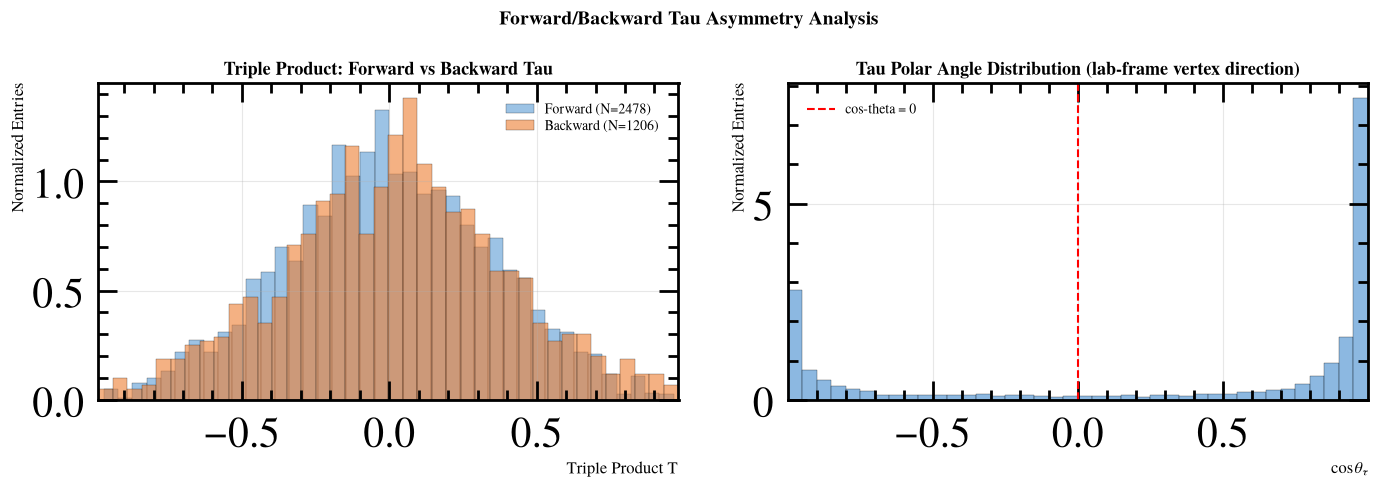

In [69]:
# =============================================================================
# FORWARD/BACKWARD TAU ASYMMETRY -- lab-frame vertex direction
# (see the frame discussion above)
# =============================================================================

tau_dir_x = df_all["taux"] - df_all["IPX"]
tau_dir_y = df_all["tauy"] - df_all["IPY"]
tau_dir_z = df_all["tauz"] - df_all["IPZ"]

tau_p = np.sqrt(tau_dir_x**2 + tau_dir_y**2 + tau_dir_z**2)
tau_cos_theta = tau_dir_z / tau_p
df_all["tau_cos_theta"] = tau_cos_theta

signal_mask = df_all["sigissig"] == 1
signal_df = df_all[signal_mask]

forward_mask = signal_df["tau_cos_theta"] > 0
backward_mask = signal_df["tau_cos_theta"] < 0

triple_forward = signal_df.loc[forward_mask, "triple_product_reco"].dropna()
triple_backward = signal_df.loc[backward_mask, "triple_product_reco"].dropna()

N_plus_fwd = int(np.sum(triple_forward > 0))
N_minus_fwd = int(np.sum(triple_forward < 0))
A_T_fwd, A_T_fwd_err = asymmetry_with_error(N_plus_fwd, N_minus_fwd)

N_plus_bwd = int(np.sum(triple_backward > 0))
N_minus_bwd = int(np.sum(triple_backward < 0))
A_T_bwd, A_T_bwd_err = asymmetry_with_error(N_plus_bwd, N_minus_bwd)

N_forward = len(triple_forward)
N_backward = len(triple_backward)
A_FB, A_FB_err = asymmetry_with_error(N_forward, N_backward)

A_T_diff = A_T_fwd - A_T_bwd
A_T_diff_err = np.sqrt(A_T_fwd_err**2 + A_T_bwd_err**2)

print("=" * 60)
print("FORWARD/BACKWARD TAU ASYMMETRY (lab-frame vertex direction)")
print("=" * 60)
print(f"Forward events (cos-theta > 0):  {N_forward}")
print(f"Backward events (cos-theta < 0): {N_backward}")
print(f"Forward-Backward asymmetry: {A_FB:.4f} +/- {A_FB_err:.4f}")
print()
print("Triple product asymmetry:")
print(f"  Forward:  A_T = {A_T_fwd:.4f} +/- {A_T_fwd_err:.4f}  (N_plus={N_plus_fwd}, N_minus={N_minus_fwd})")
print(f"  Backward: A_T = {A_T_bwd:.4f} +/- {A_T_bwd_err:.4f}  (N_plus={N_plus_bwd}, N_minus={N_minus_bwd})")
print(f"  Difference: {A_T_diff:.4f} +/- {A_T_diff_err:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(triple_forward, bins=40, density=True, alpha=0.6, color='#5B9BD5',
        edgecolor='black', linewidth=0.3, label=f'Forward (N={N_forward})')
ax.hist(triple_backward, bins=40, density=True, alpha=0.6, color='#ED7D31',
        edgecolor='black', linewidth=0.3, label=f'Backward (N={N_backward})')
ax.set_xlabel(r'Triple Product $\mathcal{T}$', fontsize=12)
ax.set_ylabel('Normalized Entries', fontsize=12)
ax.set_title('Triple Product: Forward vs Backward Tau', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(signal_df["tau_cos_theta"].dropna(), bins=40, density=True, alpha=0.7,
        color='#5B9BD5', edgecolor='black', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='cos-theta = 0')
ax.set_xlabel(r'cos$\theta_{\tau}$', fontsize=12)
ax.set_ylabel('Normalized Entries', fontsize=12)
ax.set_title('Tau Polar Angle Distribution (lab-frame vertex direction)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Forward/Backward Tau Asymmetry Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Cross-check: Upsilon(4S) CMS-frame tau direction

Same asymmetry calculation, but using the tau momentum direction as
reconstructed directly in the Upsilon(4S) CMS frame (`taupxcms`,
`taupycms`, `taupzcms`) rather than the lab-frame vertex direction above.

**This is still not the B-rest-frame direction** -- it is kept here only as a cross-check against the lab-frame
version, and is explicitly *not* presented as the final $A_{FB}$ result.


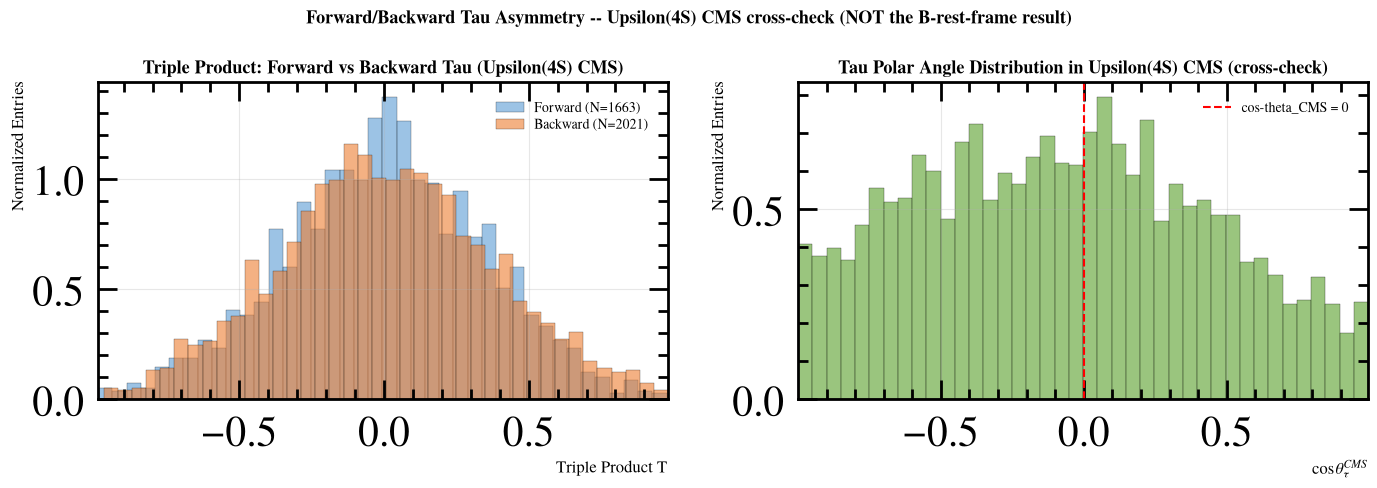

FORWARD/BACKWARD TAU ASYMMETRY (Upsilon(4S) CMS frame, cross-check)
Forward events (cos-theta > 0):  1663
Backward events (cos-theta < 0): 2021
Forward-Backward asymmetry: -0.0972 +/- 0.0164

Triple product asymmetry:
  Forward (CMS):  A_T = 0.0150 +/- 0.0245
  Backward (CMS): A_T = -0.0074 +/- 0.0222
  Difference:       0.0225 +/- 0.0331

Reminder: the physically correct A_FB needs the tau direction boosted


In [70]:
# =============================================================================
# FORWARD/BACKWARD TAU ASYMMETRY -- Upsilon(4S) CMS frame (cross-check only,
# NOT the B-rest-frame quantity)
# =============================================================================

tau_px_cms = df_all["taupxcms"]
tau_py_cms = df_all["taupycms"]
tau_pz_cms = df_all["taupzcms"]

tau_p_cms = np.sqrt(tau_px_cms**2 + tau_py_cms**2 + tau_pz_cms**2)
df_all["tau_cos_theta_CMS"] = tau_pz_cms / tau_p_cms

signal_mask = df_all["sigissig"] == 1
signal_df = df_all[signal_mask]

forward_mask = signal_df["tau_cos_theta_CMS"] > 0
backward_mask = signal_df["tau_cos_theta_CMS"] < 0

triple_forward = signal_df.loc[forward_mask, "triple_product_reco"].dropna()
triple_backward = signal_df.loc[backward_mask, "triple_product_reco"].dropna()

N_plus_fwd = int(np.sum(triple_forward > 0))
N_minus_fwd = int(np.sum(triple_forward < 0))
A_T_fwd, A_T_fwd_err = asymmetry_with_error(N_plus_fwd, N_minus_fwd)

N_plus_bwd = int(np.sum(triple_backward > 0))
N_minus_bwd = int(np.sum(triple_backward < 0))
A_T_bwd, A_T_bwd_err = asymmetry_with_error(N_plus_bwd, N_minus_bwd)

N_forward = len(triple_forward)
N_backward = len(triple_backward)
A_FB, A_FB_err = asymmetry_with_error(N_forward, N_backward)

A_T_diff = A_T_fwd - A_T_bwd
A_T_diff_err = np.sqrt(A_T_fwd_err**2 + A_T_bwd_err**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(triple_forward, bins=40, density=True, alpha=0.6, color='#5B9BD5',
        edgecolor='black', linewidth=0.3, label=f'Forward (N={N_forward})')
ax.hist(triple_backward, bins=40, density=True, alpha=0.6, color='#ED7D31',
        edgecolor='black', linewidth=0.3, label=f'Backward (N={N_backward})')
ax.set_xlabel(r'Triple Product $\mathcal{T}$', fontsize=12)
ax.set_ylabel('Normalized Entries', fontsize=12)
ax.set_title('Triple Product: Forward vs Backward Tau (Upsilon(4S) CMS)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(signal_df["tau_cos_theta_CMS"].dropna(), bins=40, density=True, alpha=0.7,
        color='#70AD47', edgecolor='black', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='cos-theta_CMS = 0')
ax.set_xlabel(r'cos$\theta_{\tau}^{CMS}$', fontsize=12)
ax.set_ylabel('Normalized Entries', fontsize=12)
ax.set_title('Tau Polar Angle Distribution in Upsilon(4S) CMS (cross-check)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Forward/Backward Tau Asymmetry -- Upsilon(4S) CMS cross-check '
             '(NOT the B-rest-frame result)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("=" * 60)
print("FORWARD/BACKWARD TAU ASYMMETRY (Upsilon(4S) CMS frame, cross-check)")
print("=" * 60)
print(f"Forward events (cos-theta > 0):  {N_forward}")
print(f"Backward events (cos-theta < 0): {N_backward}")
print(f"Forward-Backward asymmetry: {A_FB:.4f} +/- {A_FB_err:.4f}")
print()
print("Triple product asymmetry:")
print(f"  Forward (CMS):  A_T = {A_T_fwd:.4f} +/- {A_T_fwd_err:.4f}")
print(f"  Backward (CMS): A_T = {A_T_bwd:.4f} +/- {A_T_bwd_err:.4f}")
print(f"  Difference:       {A_T_diff:.4f} +/- {A_T_diff_err:.4f}")
print()
print("Reminder: the physically correct A_FB needs the tau direction boosted") #CHECK AFTERWARDS 

